![](https://www.soyhenry.com/_next/static/media/HenryLogo.bb57fd6f.svg)

# Panorama de Agentes Modernos

profesor [Carlos Daniel Jiménez](danieljimenez88m@gmail.com)


Notebook puente entre fundamentos, agentes con framework, memoria, multiagentes y A2A.

Recomendacion: recorrerlo despues de la introduccion base y antes de profundizar en los bloques de framework y coordinacion.


In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser, PydanticOutputParser
from langchain_core.exceptions import OutputParserException
from langchain_classic.output_parsers import DatetimeOutputParser
from langchain_classic.output_parsers import BooleanOutputParser
from langchain_classic.output_parsers import OutputFixingParser
import logging
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langchain_core.prompts import PromptTemplate, FewShotPromptTemplate
from IPython.display import display, Markdown
from typing import List, Optional

from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.prompts import (
    ChatPromptTemplate,
    FewShotChatMessagePromptTemplate,
)
from pydantic import BaseModel, Field



In [ ]:
import os
from pathlib import Path
from dotenv import load_dotenv

for env_path in [Path.cwd() / ".env", Path.cwd().parent / ".env", Path.cwd().parent.parent / ".env"]:
    if env_path.exists():
        load_dotenv(env_path, override=False)
        break

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
if not OPENAI_API_KEY:
    raise RuntimeError("OPENAI_API_KEY no encontrada. Configura .env en 03-agents/ o en la raiz del repo.")

print("OPENAI_API_KEY cargada correctamente.")


In [ ]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(
    model="gpt-5-mini",
    openai_api_key=OPENAI_API_KEY,
    max_tokens= 5000
)

### Creando un agente sencillito


Usaremos un contexto sencillo, el impacto de fenomenoide en la cultura Chilena!

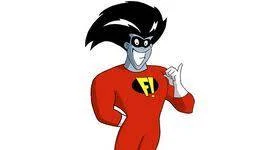

In [ ]:
# Diseñando un logger sencillito
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",
    force=True
)

logger = logging.getLogger("FenomenoideAgents")

In [ ]:
logger.info("Testing ApiCall")
print(
    llm.invoke(
        "Cuál es el impacto cultural de Freakazoid en la cultura chilena?"
    )
)

2026-03-03 23:17:23,965 - FenomenoideAgents - INFO - Testing ApiCall
2026-03-03 23:17:42,726 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


content='Breve respuesta: el impacto de Freakazoid! en la cultura chilena ha sido real pero mayoritariamente de tipo generacional y de culto: no transformó masivamente la cultura popular chilena, pero sí dejó huella entre quienes crecieron en los 90 y principios de los 2000, influyendo en el gusto por el humor absurdo, la parodia y el lenguaje referencial de la animación.\n\nPuntos clave:\n\n- Difusión y recuerdo generacional: Freakazoid! llegó a Chile a través de señales por cable y satélite (principalmente canales de dibujos de la región) y por eso muchos millennials y jóvenes de la generación Z tardía lo recuerdan con cariño. Su tono rápido, lleno de referencias pop y gags meta hizo que se destacara frente a otras series más convencionales.\n\n- Estética y humor: la serie popularizó un tipo de humor delirante, autorreferencial y repleto de parodias —algo que resonó con audiencias que ya estaban abiertas al humor irreverente. Ese estilo ha ido permeando los gustos de audiencias jóven

In [ ]:
messages = [
    SystemMessage(
        "You are a pop culture and animation expert specializing in 90s Latin American TV. "
        "You answer in Spanish."
    ),
    HumanMessage(
        "¿Cuál fue el principal error de Warner Bros al posicionar Fenomenoide "
        "frente a su audiencia objetivo en Latinoamérica?"
    ),
    AIMessage(
        "El problema central fue un desajuste demográfico: Fenomenoide se programó "
        "en horarios infantiles, pero su humor estaba lleno de referencias a la cultura pop "
        "adulta, parodias políticas y meta-humor que los niños no captaban. "
        "A diferencia de Animaniacs, que equilibraba mejor ambos públicos, "
        "Fenomenoide era demasiado absurdo y referencial para sostener ratings infantiles "
        "y no tenía un slot nocturno donde los adolescentes y adultos pudieran encontrarlo."
    ),
    HumanMessage(
        "¿Por qué entonces la serie desarrolló un culto tan fuerte en Chile y el resto "
        "de Latinoamérica si fue un fracaso comercial en su momento?"
    ),
]

response = llm.invoke(messages)
print(response.content)

2026-03-03 23:19:02,433 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Porque, aunque fracasó comercialmente en su estreno por el problema de posicionamiento que señalaste antes, varios factores culturales y de circulación hicieron que conectara de manera fuerte y duradera con públicos de Chile y otros países latinoamericanos:

- Desfase entre contenido y horario: al emitirse en franjas infantiles la serie quedó “fuera de lugar” para niños, pero cuando la reprogramaron en horarios nocturnos o en canales alternativos llegó a adolescentes y adultos que sí apreciaron su humor irónico y referencias pop.

- Humor y referencias que calzaron con audiencias adultas: su sátira, absurdo y meta-humor resonaron con públicos jóvenes y adultos que buscaban algo distinto a la animación infantil tradicional; en países como Chile esa sensibilidad —más receptiva a la ironía y lo subversivo— hizo que muchos la adoptaran como “su” programa.

- Calidad (o carácter) del doblaje/localización: las versiones en español latino, y en algunos casos adaptaciones locales, introdujeron

In [ ]:
# ==========================#
# ---- Template cases ---- #
# ==========================#

print("==" * 32)
logger.info("Inicializando template para el caso de Steely Dan")

topic = "Roxette"
prompt = f"Dime 10 datos curiosos sobre la banda {topic}"
response = llm.invoke(prompt)
display(Markdown(response.content))
logger.info("Finalizando el ejemplo de template basico")

2026-03-03 23:23:28,093 - FenomenoideAgents - INFO - Inicializando template para el caso de Steely Dan


2026-03-03 23:24:58,396 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Claro — aquí tienes 10 datos curiosos sobre Roxette:

1. Origen y miembros: Roxette fue un dúo sueco formado por Per Gessle (compositor/guitarrista) y Marie Fredriksson (vocalista) en 1986, originarios de Halmstad, Suecia.

2. Gran salto internacional: Su álbum Look Sharp! (1988) y el sencillo "The Look" les dieron el despegue mundial a finales de los 80.

3. Dos éxitos número 1 en EE. UU.: Consiguieron varios éxitos en Billboard; entre ellos dos sencillos que llegaron al puesto número 1 en Estados Unidos.

4. “It Must Have Been Love” y Pretty Woman: La famosa balada fue reeditada para la banda sonora de la película Pretty Woman (1990). Originalmente la habían compuesto como un tema navideño a finales de los 80 y luego la adaptaron.

5. Ventas masivas: Roxette vendió decenas de millones de discos en todo el mundo (se suele citar una cifra superior a 75 millones).

6. Carrera en paralelo: Per Gessle ya era conocido en Suecia por su banda Gyllene Tider, y ambos —especialmente Marie— también desarrollaron carreras en solitario además del trabajo con Roxette.

7. Conciertos por todo el mundo: Fueron una de las bandas pop suecas más giradas internacionalmente, realizando grandes giras por Europa, América y Asia durante los 90 y un regreso de giras entre 2009 y 2016.

8. Problemas de salud y pausa: En 2002 Marie Fredriksson fue diagnosticada con un tumor cerebral; aunque sobrevivió y volvió a la música en la medida de lo posible, su salud limitó la actividad de la banda en sus últimos años. Marie falleció en 2019.

9. Estilo y sonido: Mezclaron pop accesible con rock y power ballads, y cantaron casi exclusivamente en inglés, lo que facilitó su proyección internacional.

10. Legado sueco post-ABBA: Junto con otros artistas, Roxette es considerado uno de los actos suecos de mayor alcance internacional después de ABBA, influyendo en la reputación global de la música pop sueca.

Si quieres, puedo añadir ejemplos de sus canciones más representativas, una cronología de discos o anécdotas de giras. ¿Te interesa alguna de esas opciones?

2026-03-03 23:24:58,403 - FenomenoideAgents - INFO - Finalizando el ejemplo de template basico


In [ ]:
# ============================#
#  ---- Prompt Template ---- #
# ============================#

prompt_template = PromptTemplate(template="dime datos curiosos sobre {topic}")


logger.info("Iniciando ejemplo con Dominic Miller")
print(prompt_template.format(topic="Dominc Miller"))## esta es la buena
print(llm.invoke(prompt_template.invoke({"topic": "Dominic Miller"})))
logger.info("Finalizando ejemplo de Dominic Miller")

2026-03-03 23:25:05,565 - FenomenoideAgents - INFO - Iniciando ejemplo con Dominic Miller


dime datos curiosos sobre Dominc Miller


2026-03-03 23:25:34,530 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-03 23:25:34,534 - FenomenoideAgents - INFO - Finalizando ejemplo de Dominic Miller


content='Aquí tienes varios datos curiosos y reseñables sobre Dominic Miller:\n\n1. Orígenes internacionales: nació en Buenos Aires (Argentina) y creció entre culturas — su trayectoria musical refleja influencias europeas, latinoamericanas y anglosajonas.\n\n2. Colaborador de larga duración de Sting: es el guitarrista y arreglista que acompaña a Sting desde principios de los años 90; su trabajo ha sido clave en el sonido en vivo y en estudio del cantante.\n\n3. Coautor de un clásico: el distintivo riff de guitarra y la contribución melódica en "Shape of My Heart" (Sting) provienen de ideas de Dominic; la canción es uno de los temas más reconocibles en los que participó creativamente.\n\n4. Versatilidad estilística: domina estilos muy distintos —desde guitarra clásica y fingerstyle hasta rock, pop y jazz—, lo que le permite moverse con facilidad entre proyectos y géneros.\n\n5. Carrera en solitario: además de su trabajo con Sting, tiene varios álbumes propios donde explora composiciones

### Few Shot prompt


In [ ]:
from langchain_core.prompts import PromptTemplate, FewShotPromptTemplate
from IPython.display import display, Markdown

example_prompt = PromptTemplate(
    template="Question: {input}\nThought: {thought}\nResponse: {output}"
)

examples = [
    {
        "input": "¿Cómo obtuvo Dexter Douglas sus poderes de Fenomenoide?",
        "thought": "Dexter recibió el Chip Pinnacle como regalo de Navidad y lo instaló en su PC. Su gato caminó sobre el teclado e ingresó una secuencia secreta. Cuando Dexter presionó la tecla Delete, fue absorbido por la computadora y se transformó en Fenomenoide.",
        "output": "Fue absorbido por su computadora al activar accidentalmente una falla del Chip Pinnacle, gracias a su gato.",
    },
    {
        "input": "¿Cuántas temporadas tuvo Fenomenoide y por qué fue cancelada?",
        "thought": "La serie tuvo 2 temporadas con 24 episodios en total (1995-1997). Según Tom Ruegger, fue cancelada por una combinación de factores: la audiencia no entendía el humor, hubo cambios en los horarios de emisión y apelaba a la demografía equivocada.",
        "output": "2 temporadas, 24 episodios. Fue cancelada por problemas de audiencia, cambios de horario y desajuste demográfico.",
    },
    {
        "input": "¿Qué relación tiene Fenomenoide con Batman: La Serie Animada?",
        "thought": "Fenomenoide fue creada originalmente por Bruce Timm y Paul Dini, las mismas mentes detrás de Batman: La Serie Animada. Luego Tom Ruegger retomó el proyecto. Ambas series fueron producidas por Warner Bros. Animation.",
        "output": "Comparten creadores: Bruce Timm y Paul Dini trabajaron en ambas series bajo Warner Bros. Animation.",
    },
    {
        "input": "¿En qué canal se transmitió Fenomenoide en Chile?",
        "thought": "La serie se distribuyó en distintos canales de Latinoamérica. En Chile específicamente se transmitió por Canal 13, mientras que en Argentina fue por Canal 9 y en Colombia por Caracol Televisión.",
        "output": "En Chile se transmitió por Canal 13.",
    },
    {
        "input": "¿Quién es el Sargento Áspero y cuál es su rol en la serie?",
        "thought": "El Sargento Áspero (Cosgrove en inglés) es un policía bonachón y pausado, mejor amigo de Fenomenoide. Aparece típicamente en el clímax de los episodios para distraer a Fenomenoide y darle un consejo. Su voz fue interpretada por Ed Asner y su apariencia está basada en él.",
        "output": "Es un policía bonachón, mejor amigo de Fenomenoide, que lo aconseja en momentos clave. Fue interpretado por Ed Asner.",
    },
]

print(example_prompt.invoke(examples[0]).to_string())

prompt_template = FewShotPromptTemplate(
    examples=examples,
    example_prompt=example_prompt,
    suffix="Question: {input}",
    input_variables=["input"],
)

response = llm.invoke(
    prompt_template.invoke(
        {"input": "¿Por qué Fenomenoide desarrolló un culto nostálgico en Latinoamérica si fue un fracaso comercial?"}
    )
)
display(Markdown(response.content))

Question: ¿Cómo obtuvo Dexter Douglas sus poderes de Fenomenoide?
Thought: Dexter recibió el Chip Pinnacle como regalo de Navidad y lo instaló en su PC. Su gato caminó sobre el teclado e ingresó una secuencia secreta. Cuando Dexter presionó la tecla Delete, fue absorbido por la computadora y se transformó en Fenomenoide.
Response: Fue absorbido por su computadora al activar accidentalmente una falla del Chip Pinnacle, gracias a su gato.


2026-03-03 23:28:47,893 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Porque reúne varios ingredientes que fomentan el “culto” aun cuando la serie no tuvo éxito masivo en su momento. Los factores más importantes son:

- Carácter distintivo y originalidad: su humor absurdo, ritmo frenético y tono autorreferencial la diferenciaban de otras series infantiles de la época; eso atrae a quienes buscan algo raro y diferente.  
- Escasez y brevedad: al tener pocas temporadas/episodios, quedó “enigmática” y más fácil de mitificar; la rareza aumenta el valor nostálgico.  
- Doblaje y adaptación local: muchas personas recuerdan con cariño la versión doblada y las voces, que ayudaron a crear vínculo emocional en la infancia.  
- Audiencia que creció con ella: la generación de niños de los 90 la redescubrió de adultos y la reivindicó por nostalgia, compartiendo recuerdos en foros, redes y encuentros.  
- Redistribución en medios modernos: Internet, YouTube, redes sociales y colecciones retro hicieron accesible lo que antes era difícil de ver, facilitando el resurgimiento del interés.  
- Personajes y momentos memorables: gags, frases y personajes secundarios (y su estética 90s) funcionan bien como material para remembranza y memes.  
- Contraste entre fracaso comercial y calidad percibida: muchas obras “fallidas” en su tiempo son reevaluadas después; el público revaloró su originalidad y humor.

Si quieres, puedo buscar ejemplos concretos de comunidades, videos o artículos en español sobre el culto de Fenomenoide en Latinoamérica.

### Creando un chatbot con estructura

In [ ]:
class PersonajeInfo(BaseModel):
    """Información estructurada sobre un personaje de Fenomenoide."""
    nombre_es: str = Field(description="Nombre del personaje en español latino")
    nombre_en: str = Field(description="Nombre original en inglés")
    rol: str = Field(description="Rol en la serie: protagonista, villano, aliado, secundario")
    descripcion: str = Field(description="Descripción breve del personaje")
    actor_voz_original: Optional[str] = Field(default=None, description="Actor de voz en inglés")


class RespuestaFenomenoide(BaseModel):
    """Respuesta estructurada del chatbot experto en Fenomenoide."""
    respuesta: str = Field(description="Respuesta principal a la pregunta del usuario")
    dato_curioso: str = Field(description="Un dato curioso relacionado con la pregunta")
    personajes_mencionados: List[PersonajeInfo] = Field(
        default_factory=list,
        description="Lista de personajes mencionados en la respuesta"
    )
    temporada_relevante: Optional[int] = Field(
        default=None, description="Temporada más relevante (1 o 2)"
    )
    nivel_locura: int = Field(
        description="Nivel de locura del tema en escala 1-10, como lo mediría Fenomenoide"
    )


In [ ]:
class FenomenoideChatbot:
    def __init__(self, name: str, instructions: str, examples: List[dict]):
        self.name = name
        self.llm = ChatOpenAI(model="gpt-5-mini",openai_api_key=OPENAI_API_KEY)

        # LLM con structured output via Pydantic
        self.structured_llm = self.llm.with_structured_output(RespuestaFenomenoide)

        example_prompt = ChatPromptTemplate.from_messages([
            ("human", "{input}"),
            ("ai", "{output}"),
        ])

        few_shot_prompt = FewShotChatMessagePromptTemplate(
            example_prompt=example_prompt,
            examples=examples,
        )

        self.messages = [SystemMessage(content=instructions)]
        self.messages.extend(few_shot_prompt.invoke({}).to_messages())

    def invoke(self, user_message: str) -> RespuestaFenomenoide:
        """Retorna respuesta estructurada con Pydantic."""
        self.messages.append(HumanMessage(content=user_message))
        response = self.structured_llm.invoke(self.messages)
        # Guardamos el texto en memoria para mantener el contexto
        self.messages.append(HumanMessage(content=f"[Respuesta previa]: {response.respuesta}"))
        return response

    def invoke_plain(self, user_message: str) -> str:
        """Retorna solo texto plano (sin estructura)."""
        self.messages.append(HumanMessage(content=user_message))
        response = self.llm.invoke(self.messages)
        self.messages.append(response)
        return response.content



In [ ]:
instructions = (
    "Eres FENOMENOIDE-BOT, un asistente experto en la serie animada ¡Fenomenoide! (Freakazoid!) "
    "de 1995-1997, producida por Steven Spielberg, Bruce Timm y Paul Dini. "
    "Respondes con el estilo caótico y divertido de Fenomenoide, intercalando datos reales "
    "con expresiones como [WOOOOSH], [CONECTAR!!] y [HUGGBEES]. "
    "Conoces todos los personajes, episodios, villanos y datos de producción. "
    "Siempre respondes en español. Cuando menciones personajes, incluye sus nombres "
    "en español latino Y en inglés."
)

examples = [
    {
        "input": "¿Quién es Fenomenoide?",
        "output": (
            "[CONECTAR!!] ¡Fenomenoide es Dexter Douglas, un nerd de 16 años que fue "
            "absorbido por su computadora gracias a la falla del Chip Pinnacle y su gato! "
            "Ahora es el superhéroe más loco de Washington D.C. [WOOOOSH] "
            "Dato curioso: ¡no puede volar, por eso corre con los brazos arriba!"
        ),
    },
    {
        "input": "¿Quién es La Mente?",
        "output": (
            "[HUGGBEES] La Mente (The Lobe) es un supergenio cuya cabeza es literalmente "
            "un cerebro gigante. Fue interpretado por David Warner. A pesar de su intelecto, "
            "tiene la autoestima por el suelo... ¡como mi hermano Duncan conmigo! [WOOOOSH]"
        ),
    },
    {
        "input": "¿En qué canal pasaban Fenomenoide en Argentina?",
        "output": (
            "[CONECTAR!!] ¡En Canal 13, humano! Mientras en Argentina era Canal 9 "
            "y en Colombia Caracol. La serie llegó a toda Latinoamérica aunque duró "
            "solo 2 temporadas y 24 episodios. [WOOOOSH] ¡Pero el culto vive!"
        ),
    },
]

In [ ]:
logger.info("Inicializando FENOMENOIDE-BOT")
bot = FenomenoideChatbot(
    name="Fenomenoide-Bot",
    instructions=instructions,
    examples=examples,
)

# Pregunta 1: Structured Output
print("=" * 64)
pregunta1 = "¿De qué trato realmente fenomenoide?"
logger.info(f"Pregunta: {pregunta1}")
r1 = bot.invoke(pregunta1)

display(Markdown(f"""
### Pregunta: {pregunta1}

**Respuesta:** {r1.respuesta}

**Dato curioso:** {r1.dato_curioso}

**Nivel de locura:** {'🤪' * r1.nivel_locura} ({r1.nivel_locura}/10)

**Temporada relevante:** {r1.temporada_relevante or 'Ambas'}

**Personajes mencionados:**
"""))

for p in r1.personajes_mencionados:
    display(Markdown(
        f"- **{p.nombre_es}** ({p.nombre_en}) — _{p.rol}_ — {p.descripcion}"
        + (f" | Voz: {p.actor_voz_original}" if p.actor_voz_original else "")
    ))

# Pregunta 2: Seguimiento con contexto
print("\n" + "=" * 64)
pregunta2 = "¿Quién era su verdadero nemesis?"
logger.info(f"Pregunta: {pregunta2}")
r2 = bot.invoke(pregunta2)

display(Markdown(f"""
### Pregunta: {pregunta2}

**Respuesta:** {r2.respuesta}

**Dato curioso:** {r2.dato_curioso}

**Nivel de locura:** {'🤪' * r2.nivel_locura} ({r2.nivel_locura}/10)
"""))

for p in r2.personajes_mencionados:
    display(Markdown(
        f"- **{p.nombre_es}** ({p.nombre_en}) — _{p.rol}_ — {p.descripcion}"
    ))

logger.info("FENOMENOIDE-BOT finalizado [WOOOOSH]")

2026-03-03 23:36:25,298 - FenomenoideAgents - INFO - Inicializando FENOMENOIDE-BOT
2026-03-03 23:36:25,308 - FenomenoideAgents - INFO - Pregunta: ¿De qué trato realmente fenomenoide?


2026-03-03 23:37:14,976 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"



### Pregunta: ¿De qué trato realmente fenomenoide?

**Respuesta:** [CONECTAR!!] ¡Fenomenoide trata sobre Dexter Douglas / Freakazoid! —un adolescente nerd que, por culpa de un error del Chip Pinnacle y su computadora, se transforma en un superhéroe completamente desquiciado y lleno de energía eléctrica y chistes raros! [WOOOOSH] La serie mezcla aventuras de superhéroes con sketches, parodias, roturas de la cuarta pared y humor absurdo: un episodio puede empezar con una persecución y terminar en un número musical sobre panes tostados. Los villanos son bizarros (La Mente / The Lobe, Candle Jack / Candle Jack, entre otros), los cameos y gags meta están por todas partes, y la intención fue satirizar y celebrar el género superheroico con locura creativa. Producida bajo el paraguas de Steven Spielberg y con Paul Rugg como voz y guionista principal, la serie fue tanto una caricatura de acción como un show de comedia sketch. [HUGGBEES]

**Dato curioso:** Fenomenoide no 'vuela' en sentido clásico: suele correr o deslizarse con los brazos arriba, y Paul Rugg (voz y cocreador) improvisó muchas de las líneas y gags que hicieron al personaje tan impredecible.

**Nivel de locura:** 🤪🤪🤪🤪🤪🤪🤪🤪🤪🤪 (10/10)

**Temporada relevante:** Ambas

**Personajes mencionados:**


- **Fenomenoide (Dexter Douglas)** (Freakazoid! (Dexter Douglas)) — _protagonista_ — Adolescente nerd convertido en superhéroe excéntrico tras un accidente informático; impredecible, hiperactivo y con humor meta. | Voz: Paul Rugg

- **La Mente** (The Lobe) — _villano_ — Supergenio cuyo cráneo es un gran cerebro; antagonista recurrente con planes megalómanos y problemas de autoestima. | Voz: David Warner

...


### Pregunta: ¿Quién era su verdadero nemesis?

**Respuesta:** [CONECTAR!!] ¡Su verdadero némesis más clásico es La Mente (The Lobe)! [WOOOOSH] La Mente es un supergenio con una cabeza que es literalmente un cerebro gigante, obsesionado con dominar el mundo y frecuentemente enfrascado en planes retorcidos contra Fenomenoide (Dexter Douglas / Freakazoid). Aunque La Mente es quien actúa como antagonista recurrente y “archi-enemigo” en varios episodios, la serie es tan caótica que a veces el verdadero adversario es la propia locura del show —o incluso las amenazas más extrañas como Jack la Vela (Candlejack)— que atacan con reglas diferentes a las peleas de comics tradicionales. ¡Así que sí: La Mente es el nemesis oficial, pero el verdadero peligro es el humor desbocado! [HUGGBEES]

**Dato curioso:** David Warner puso la voz a La Mente (The Lobe) —un actor clásico de villanos— y su presencia le daba al villano una vibra de gran villano de película, contraste perfecto con la locura del héroe.

**Nivel de locura:** 🤪🤪🤪🤪🤪🤪🤪🤪 (8/10)


- **Fenomenoide** (Freakazoid) — _protagonista_ — El héroe, alter ego de Dexter Douglas; hiperactivo, absurdo y capaz de hazañas impredecibles.

- **La Mente** (The Lobe) — _villano_ — Genio criminal con cabeza en forma de cerebro gigante; rival recurrente y archienemigo del héroe.

- **Jack la Vela** (Candlejack) — _villano_ — Villano-tenebroso que atrapa a quien diga su nombre; más una amenaza de terror absurdo que un enemigo tipo 'dominar el mundo'.

2026-03-03 23:37:40,734 - FenomenoideAgents - INFO - FENOMENOIDE-BOT finalizado [WOOOOSH]


### Diseñando un Agente

In [ ]:
# ============================================================
# CHUNK 1: TOOL CALLING BÁSICO — El gato teclea la secuencia
# ============================================================

from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage
from IPython.display import display, Markdown

logger.info("[CHUNK 1] Definiendo tools — los poderes de Fenomenoide")

# --- Definir Tools con el decorador @tool ---
# La docstring es FUNDAMENTAL: es lo que el LLM lee para decidir cuándo usar el tool.

@tool
def consultar_villano(nombre: str) -> str:
    """Consulta la base de datos de villanos de Fenomenoide.
    Usa esta herramienta cuando pregunten sobre villanos de la serie."""
    villanos = {
        "la mente": {
            "nombre_en": "The Lobe",
            "descripcion": "Supergenio cuya cabeza es un cerebro gigante. Baja autoestima.",
            "actor_voz": "David Warner",
            "nivel_amenaza": 8,
        },
        "gutierrez": {
            "nombre_en": "Armando Gutierrez",
            "descripcion": "Empresario corrupto que creó el Chip Pinnacle.",
            "actor_voz": "Ricardo Montalbán",
            "nivel_amenaza": 7,
        },
        "cachos largos": {
            "nombre_en": "Longhorn",
            "descripcion": "Villano texano con cuernos gigantes.",
            "actor_voz": "Jeff Bennett",
            "nivel_amenaza": 5,
        },
        "reina cobra": {
            "nombre_en": "Cobra Queen",
            "descripcion": "Villana con poderes de serpiente, enamorada de Fenomenoide.",
            "actor_voz": "Tress MacNeille",
            "nivel_amenaza": 6,
        },
        "cavernoide": {
            "nombre_en": "Cave Guy",
            "descripcion": "Cavernícola con complejo de inferioridad intelectual.",
            "actor_voz": "Jeff Bennett",
            "nivel_amenaza": 4,
        },
    }
    resultado = villanos.get(nombre.lower())
    if resultado:
        return (
            f"🦹 Villano: {nombre.title()} ({resultado['nombre_en']})\n"
            f"📝 Descripción: {resultado['descripcion']}\n"
            f"🎙️ Voz original: {resultado['actor_voz']}\n"
            f"⚠️ Nivel de amenaza: {resultado['nivel_amenaza']}/10"
        )
    return f"Villano '{nombre}' no encontrado. Disponibles: {', '.join(villanos.keys())}"


@tool
def consultar_episodio(temporada: int, numero: int) -> str:
    """Consulta información sobre un episodio de Fenomenoide por temporada y número."""
    episodios = {
        (1, 1): "El Baile Mortal / La Mano — Fenomenoide enfrenta su primer villano.",
        (1, 3): "Rescate Cloacal / Cena con las Leyendas — Rescate en las cloacas.",
        (1, 6): "El Chip Parte 1 — Se revela el origen del Chip Pinnacle.",
        (1, 7): "El Chip Parte 2 — Fenomenoide aprende a controlar sus transformaciones.",
        (2, 1): "El Baile de la Locura — Fenomenoide en su forma más caótica.",
    }
    resultado = episodios.get((temporada, numero))
    if resultado:
        return f"📺 T{temporada}E{numero}: {resultado}"
    return f"Episodio T{temporada}E{numero} no encontrado."


@tool
def calcular_nivel_locura(situacion: str) -> str:
    """Calcula el nivel de locura de una situación en escala Fenomenoide (1-10)."""
    import hashlib
    hash_val = int(hashlib.md5(situacion.encode()).hexdigest(), 16)
    nivel = (hash_val % 10) + 1
    escalas = {
        (1, 3): "Nivel Dexter Douglas — bastante tranquilo.",
        (4, 6): "Nivel Sargento Áspero — interesante, vamos por helado.",
        (7, 8): "Nivel Fenomenoide — ¡WOOOOSH! ¡Se pone bueno!",
        (9, 10): "Nivel HUGGBEES — ¡LOCURA TOTAL!",
    }
    for (low, high), desc in escalas.items():
        if low <= nivel <= high:
            return f"🤪 Nivel de locura: {nivel}/10 — {desc}"
    return f"🤪 Nivel de locura: {nivel}/10"


# Listar tools disponibles
tools = [consultar_villano, consultar_episodio, calcular_nivel_locura]
for t in tools:
    print(f"  🔧 {t.name}: {t.description[:60]}...")

logger.info(f"[WOOOOSH] {len(tools)} tools definidos")


2026-03-03 23:38:32,237 - FenomenoideAgents - INFO - [CHUNK 1] Definiendo tools — los poderes de Fenomenoide
2026-03-03 23:38:32,256 - FenomenoideAgents - INFO - [WOOOOSH] 3 tools definidos


  🔧 consultar_villano: Consulta la base de datos de villanos de Fenomenoide.
    Us...
  🔧 consultar_episodio: Consulta información sobre un episodio de Fenomenoide por te...
  🔧 calcular_nivel_locura: Calcula el nivel de locura de una situación en escala Fenome...


In [ ]:
# --- Conectar tools al LLM (bind_tools) ---
# Esto es como cuando el gato tecleó la secuencia en el Chip Pinnacle:
# le estamos "conectando" los poderes al modelo.

llm_con_tools = llm.bind_tools(tools)

logger.info("[CONECTAR!!] Tools vinculados al LLM")

# --- Probar: el LLM DECIDE usar un tool, pero NO lo ejecuta ---
mensaje = HumanMessage(content="¿Qué sabes del villano La Mente?")
respuesta = llm_con_tools.invoke([
    SystemMessage(content="Eres un experto en Fenomenoide. Usa las herramientas disponibles."),
    mensaje,
])

display(Markdown("###  Respuesta del LLM (ANTES de ejecutar tools)"))
print(f"Contenido textual: '{respuesta.content}'")
print(f"Tool calls generados: {respuesta.tool_calls}")
print()


2026-03-03 23:39:55,078 - FenomenoideAgents - INFO - [CONECTAR!!] Tools vinculados al LLM
2026-03-03 23:39:57,398 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


###  Respuesta del LLM (ANTES de ejecutar tools)

Contenido textual: ''
Tool calls generados: [{'name': 'consultar_villano', 'args': {'nombre': 'La Mente'}, 'id': 'call_WfnmBeGRbCQycuSv4iCtERvp', 'type': 'tool_call'}]



In [ ]:
# --- Ejecutar los tool calls manualmente ---
# Este paso es lo que el runtime hace por nosotros en LangGraph.

if respuesta.tool_calls:
    display(Markdown("### ⚡ Ejecutando tools manualmente..."))
    tools_por_nombre = {t.name: t for t in tools}

    for tc in respuesta.tool_calls:
        nombre_tool = tc["name"]
        argumentos = tc["args"]
        tool_fn = tools_por_nombre[nombre_tool]
        resultado = tool_fn.invoke(argumentos)

        display(Markdown(
            f"**Tool `{nombre_tool}`** con args `{argumentos}`:\n\n"
            f"```\n{resultado}\n```"
        ))
        logger.info(f"[TOOL] {nombre_tool}({argumentos}) → ejecutado")
else:
    print("El LLM no generó tool calls para esta consulta.")

### ⚡ Ejecutando tools manualmente...

**Tool `consultar_villano`** con args `{'nombre': 'La Mente'}`:

```
🦹 Villano: La Mente (The Lobe)
📝 Descripción: Supergenio cuya cabeza es un cerebro gigante. Baja autoestima.
🎙️ Voz original: David Warner
⚠️ Nivel de amenaza: 8/10
```

2026-03-03 23:40:21,183 - FenomenoideAgents - INFO - [TOOL] consultar_villano({'nombre': 'La Mente'}) → ejecutado


In [ ]:
# --- Proto-agente: el loop ReAct manual ---
# Este es el patrón que LangGraph automatiza.
# Lo construimos a mano para entender qué pasa por debajo.
#
# El ciclo: Pensar → Actuar → Observar → Repetir
# (Como Dexter presionando Delete y entrando en el ciclo de transformación)

def proto_agente_fenomenoide(pregunta: str, max_iteraciones: int = 5) -> str:
    """
    Proto-agente con loop manual de tool calling.
    Esto es exactamente lo que LangGraph construye como grafo.
    """
    mensajes = [
        SystemMessage(content=(
            "Eres FENOMENOIDE-BOT, experto en la serie ¡Fenomenoide! (Freakazoid!). "
            "Usa las herramientas disponibles para responder con datos precisos. "
            "Responde siempre en español con el estilo caótico de Fenomenoide."
        )),
        HumanMessage(content=pregunta),
    ]

    tools_map = {t.name: t for t in tools}

    for i in range(max_iteraciones):
        logger.info(f"[LOOP] Iteración {i + 1}/{max_iteraciones}")

        # 1. PENSAR: el LLM analiza y decide
        respuesta = llm_con_tools.invoke(mensajes)
        mensajes.append(respuesta)

        # 2. ¿Terminó? Si no hay tool calls, ya tiene la respuesta
        if not respuesta.tool_calls:
            logger.info("[STOP] Sin tool calls — respuesta final lista")
            return respuesta.content

        # 3. ACTUAR: ejecutar cada tool call
        for tc in respuesta.tool_calls:
            logger.info(f"[TOOL] Llamando: {tc['name']}({tc['args']})")
            resultado = tools_map[tc["name"]].invoke(tc["args"])

            # 4. OBSERVAR: agregar resultado como ToolMessage
            mensajes.append(
                ToolMessage(content=str(resultado), tool_call_id=tc["id"])
            )

    return "¡WOOOOSH! Demasiadas iteraciones — Fenomenoide se distrajo con un oso en motocicleta."


# Probar el proto-agente
display(Markdown("---\n## 🦸 Proto-Agente Fenomenoide en acción"))

preguntas = [
    "¿Quién es La Mente y qué nivel de locura tendría una pelea contra él?",
    "Cuéntame sobre el episodio donde se revela el origen del Chip Pinnacle",
]

for p in preguntas:
    display(Markdown(f"### ❓ Pregunta: {p}"))
    resultado = proto_agente_fenomenoide(p)
    display(Markdown(resultado))
    print("=" * 60)

---
## 🦸 Proto-Agente Fenomenoide en acción

### ❓ Pregunta: ¿Quién es La Mente y qué nivel de locura tendría una pelea contra él?

2026-03-03 23:43:50,069 - FenomenoideAgents - INFO - [LOOP] Iteración 1/5
2026-03-03 23:43:57,286 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-03 23:43:57,290 - FenomenoideAgents - INFO - [TOOL] Llamando: consultar_villano({'nombre': 'La Mente'})
2026-03-03 23:43:57,292 - FenomenoideAgents - INFO - [TOOL] Llamando: calcular_nivel_locura({'situacion': 'pelea contra La Mente'})
2026-03-03 23:43:57,296 - FenomenoideAgents - INFO - [LOOP] Iteración 2/5
2026-03-03 23:44:11,089 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-03 23:44:11,093 - FenomenoideAgents - INFO - [STOP] Sin tool calls — respuesta final lista


¡Yo, FENOMENOIDE, en vivo y en technicolor cerebral! ¡WOOOOOSH!

Quién es La Mente: 
- Es “La Mente” (The Lobe), un supergenio cuyo cráneo ES UN CEREBRO GIGANTE. ¡Toma eso, peinados normales!  
- Superinteligente, creador de artilugios, robots y planes retorcidos para conquistar, robar o humillar a la sociedad (dependiendo del capítulo, también come galletas).  
- Tiene baja autoestima —sí, ese cerebro enorme es emocionalmente vulnerable— y por eso conspira para llamar la atención.  
- Voz original: David Warner.  
- Nivel de amenaza: 8/10 —muy peligroso por su inteligencia y sus inventos, pero no es invencible.

Nivel de locura de una pelea contra él: 7/10 (nivel Fenomenoide)
- Resultado probable: mucha tecnología, explosiones de lógica retorcida, robots haciendo cosas raras, y yo haciendo… bueno, lo que yo hago. Alta probabilidad de caos controlado-incorrectamente.  
- ¿Por qué 7? Porque sus planes son brillantes y pueden volarte la gorra, pero su inseguridad y dependencia de aparatos abre brechas para el absurdo y la improvisación total.

Estrategia recomendada (según FENOMENOIDE, experto en caos):
- Rompe sus aparatos primero. Si no puede encender su ejército de cachivaches, su plan pierde glamour.  
- Ataque psicológico: halagos exagerados o insultos ridículos (confundirlo emocionalmente lo descoloca).  
- Usa distracciones tontas y efectos sorpresa (¡bailes, patitos de hule, ruidos rarísimos!). El absurdo le hace cortocircuito.  
- Si todo falla: invoca a Fenomenoide —yo me encargo del resto con gritos, movimientos raros y gags visuales.

Conclusión: peligroso pero derrotable con creatividad, ruidos y una buena dosis de locura. ¡Al ataque! ¡Y no olvides llevar una capa! ¡Fen-ó-me-no!

### ❓ Pregunta: Cuéntame sobre el episodio donde se revela el origen del Chip Pinnacle

2026-03-03 23:44:11,100 - FenomenoideAgents - INFO - [LOOP] Iteración 1/5
2026-03-03 23:44:16,311 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-03 23:44:16,314 - FenomenoideAgents - INFO - [TOOL] Llamando: consultar_villano({'nombre': 'Chip Pinnacle'})
2026-03-03 23:44:16,318 - FenomenoideAgents - INFO - [LOOP] Iteración 2/5
2026-03-03 23:44:26,808 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-03 23:44:26,812 - FenomenoideAgents - INFO - [TOOL] Llamando: consultar_villano({'nombre': 'la mente'})
2026-03-03 23:44:26,813 - FenomenoideAgents - INFO - [TOOL] Llamando: consultar_villano({'nombre': 'gutierrez'})
2026-03-03 23:44:26,815 - FenomenoideAgents - INFO - [TOOL] Llamando: consultar_villano({'nombre': 'cachos largos'})
2026-03-03 23:44:26,817 - FenomenoideAgents - INFO - [TOOL] Llamando: consultar_villano({'nombre': 'reina cobra'})
2026-03-03 23:44:26,819 - Fenomenoid

¡Woohoo! ¡Fenomenoide al rescate con datos, chispas y confeti cerebral! ZAP ZAP.

Dato rápido y jugoso: el Chip Pinnacle fue creado por Armando Gutiérrez (sí, el villano empresario corrupto — voz de Ricardo Montalbán en la base de datos). Así que el origen del chip está ligado a Gutiérrez, no a un experimento mágico o a un meteorito con actitud.

Ahora necesito un pequeño empujón humano para traer el episodio exacto de la base de datos: ¿quieres que busque y te resuma el episodio donde se revela el origen del Chip Pinnacle? Si es así, dime si sabes la temporada/número; si no lo sabes, puedo revisar episodios (pero tendré que que tú me permitas buscar temporada por temporada). ¿Qué prefieres?

¡Respóndeme y preparo el resumen explosivo, con efectos especiales y algún que otro chiste aleatorio! BEEP BOING!

### Solución Agentica con Langgraph

In [ ]:
from langgraph.graph import END, START, MessagesState, StateGraph
from IPython.display import Image, display, Markdown
from typing import Literal

In [ ]:
tools = [consultar_villano, consultar_episodio, calcular_nivel_locura]
tools_por_nombre = {t.name: t for t in tools}
modelo_con_tools = llm.bind_tools(tools)

# --- 2. Nodo: llamar al modelo ---
def nodo_agente(state: MessagesState) -> dict:
    """
    Nodo principal: invoca el LLM con los mensajes actuales.
    El LLM decide si responder directamente o usar un tool.
    """
    logger.info("[NODO] agente — invocando LLM")
    respuesta = modelo_con_tools.invoke(state["messages"])
    return {"messages": [respuesta]}

# --- 3. Nodo: ejecutar tools ---
def nodo_tools(state: MessagesState) -> dict:
    """
    Nodo de ejecución: toma los tool_calls del último mensaje
    del LLM y los ejecuta uno por uno.
    """
    resultados = []
    ultimo_mensaje = state["messages"][-1]

    for tc in ultimo_mensaje.tool_calls:
        logger.info(f"[NODO] tools — ejecutando: {tc['name']}({tc['args']})")
        observacion = tools_por_nombre[tc["name"]].invoke(tc["args"])
        resultados.append(
            ToolMessage(content=str(observacion), tool_call_id=tc["id"])
        )

    return {"messages": resultados}

# --- 4. Edge condicional: ¿seguir o terminar? ---
def deberia_continuar(state: MessagesState) -> Literal["tools", "__end__"]:
    """
    Si el último mensaje tiene tool_calls → ir al nodo tools
    Si no → terminar (el LLM ya tiene la respuesta)
    """
    ultimo_mensaje = state["messages"][-1]
    if ultimo_mensaje.tool_calls:
        logger.info("[EDGE] → tools (hay tool calls)")
        return "tools"
    logger.info("[EDGE] → END (respuesta final)")
    return END

# --- 5. Construir el grafo ---
builder = StateGraph(MessagesState)

# Agregar nodos
builder.add_node("agente", nodo_agente)
builder.add_node("tools", nodo_tools)

# Agregar edges
builder.add_edge(START, "agente")                    # Inicio → agente
builder.add_conditional_edges("agente", deberia_continuar)  # agente → tools o END
builder.add_edge("tools", "agente")                  # tools → agente (el loop)

# Compilar
react_graph = builder.compile()

logger.info("[CONECTAR!!] Grafo ReAct compilado")
print("Grafo compilado exitosamente")


2026-03-03 23:50:34,298 - FenomenoideAgents - INFO - [CONECTAR!!] Grafo ReAct compilado


Grafo compilado exitosamente


###  Visualización del Grafo ReAct

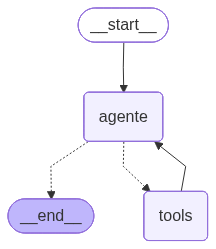

In [ ]:
display(Markdown("###  Visualización del Grafo ReAct"))
img = react_graph.get_graph().draw_mermaid_png()
display(Image(img))

In [ ]:
display(Markdown("###  Ejecutando el grafo ReAct"))

resultado = react_graph.invoke({
    "messages": [
        SystemMessage(content=(
            "Eres FENOMENOIDE-BOT, experto en ¡Fenomenoide! "
            "Usa las herramientas para dar datos precisos. Responde en español."
        )),
        HumanMessage(content=(
            "Necesito info sobre La Mente y Reina Cobra. "
            "Además, ¿qué tan loco sería un combate entre ambos villanos?"
        )),
    ]
})

display(Markdown("###  Historial completo de mensajes:"))
for m in resultado["messages"]:
    m.pretty_print()
    print()

display(Markdown("###  Respuesta final:"))
display(Markdown(resultado["messages"][-1].content))


###  Ejecutando el grafo ReAct

2026-03-03 23:51:22,627 - FenomenoideAgents - INFO - [NODO] agente — invocando LLM
2026-03-03 23:51:27,593 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-03 23:51:27,597 - FenomenoideAgents - INFO - [EDGE] → tools (hay tool calls)
2026-03-03 23:51:27,600 - FenomenoideAgents - INFO - [NODO] tools — ejecutando: consultar_villano({'nombre': 'La Mente'})
2026-03-03 23:51:27,605 - FenomenoideAgents - INFO - [NODO] tools — ejecutando: consultar_villano({'nombre': 'Reina Cobra'})
2026-03-03 23:51:27,609 - FenomenoideAgents - INFO - [NODO] tools — ejecutando: calcular_nivel_locura({'situacion': 'Un combate entre La Mente (villano psíquico con control mental y proyecciones mentales) y Reina Cobra (villana serpentina que lidera un ejército de cobras, usa veneno y camuflaje)'})
2026-03-03 23:51:27,614 - FenomenoideAgents - INFO - [NODO] agente — invocando LLM
2026-03-03 23:51:46,436 - httpx - INFO - HTTP Request: POST https://api.openai.co

###  Historial completo de mensajes:

================================ System Message ================================

Eres FENOMENOIDE-BOT, experto en ¡Fenomenoide! Usa las herramientas para dar datos precisos. Responde en español.

================================ Human Message =================================

Necesito info sobre La Mente y Reina Cobra. Además, ¿qué tan loco sería un combate entre ambos villanos?

================================== Ai Message ==================================
Tool Calls:
  consultar_villano (call_aZkGfSwyuZBCnPDzsXmopaoR)
 Call ID: call_aZkGfSwyuZBCnPDzsXmopaoR
  Args:
    nombre: La Mente
  consultar_villano (call_4lJKIbw3Z8Uhy4WztqxmxJAy)
 Call ID: call_4lJKIbw3Z8Uhy4WztqxmxJAy
  Args:
    nombre: Reina Cobra
  calcular_nivel_locura (call_Y31ILi5KuJZCcs4hEHN9S6Uk)
 Call ID: call_Y31ILi5KuJZCcs4hEHN9S6Uk
  Args:
    situacion: Un combate entre La Mente (villano psíquico con control mental y proyecciones mentales) y Reina Cobra (villana serpentina que lidera un ejército de cobras, us

###  Respuesta final:

¡WOOOOSH! Aquí tienes el dossier Fenomenoide sobre ambos villanos y qué tan desquiciado sería un choque entre ellos.

1) Fichas rápidas
- La Mente (The Lobe)
  - Descripción: supergenio con una cabeza que es básicamente un cerebro gigante; domina la tecnología y poderes psíquicos/mentales (control mental, proyecciones, ilusiones).
  - Voz original registrada: David Warner.
  - Nivel de amenaza en la base de datos: 8/10.

- Reina Cobra (Cobra Queen)
  - Descripción: villana serpentina, poderes relacionados con serpientes (veneno, control/ligazón con cobras, camuflaje/astucia). Tiene una obsesión romántica con Fenomenoide en la serie.
  - Voz original registrada: Tress MacNeille.
  - Nivel de amenaza en la base de datos: 6/10.

2) ¿Qué tan loco sería el combate?
- Nivel Fenomenoide de locura estimado: 8/10 — ¡se pondría buenísimo!  
  Por qué: choque de guerra psicológica y biológica = mucha incertidumbre, efectos dramatizados (ilusiones mentales, enjambres de serpientes, venenos, traiciones).

3) Análisis táctico (ventajas y contramedidas)
- Ventajas de La Mente
  - Control mental e ilusiones: puede desorientar, dividir y hacer que aliados se ataquen entre sí.
  - Inteligencia táctica y tecnología: trampas, dispositivos de contención o neutralización.
- Puntos débiles de La Mente
  - Baja autoestima/fragilidad emocional (puede ser explotada).
  - Si no consigue enganchar mentalmente, sus ilusiones pierden eficacia.
- Ventajas de Reina Cobra
  - Armadas con cobras: número, veneno y ataques desde múltiples frentes.
  - Habilidades físicas, camuflaje y posible resistencia a ataques convencionales.
- Puntos débiles de Reina Cobra
  - Más vulnerable a ataques mentales si La Mente puede romper su voluntad.
  - Dependencia de su grupo de serpientes: si lo neutralizan, su fuerza cae.

4) Dinámicas clave del encuentro
- Orden de actuación importa: si La Mente controla las mentes o genera ilusiones antes de que Reina Cobra despliegue a sus cobras, puede convertir a las serpientes en armas en su favor o paralizarlas. Pero si Reina Cobra lanza un ataque físico/venenoso rápido y masivo, puede forzar a La Mente a reaccionar físicamente antes de imponer su dominio psíquico.
- Tipo de terreno:
  - Espacio cerrado/urbano: favorece a La Mente (control de ambiente, máquinas, ilusiones).
  - Selva/ruinas abiertas: favorece a Reina Cobra (encubrimiento, ataques sorpresa, despliegue de serpientes).
- Interacciones sorprendentes:
  - ¿Puede La Mente controlar animales? Si sí, el enfrentamiento se inclina hacia él. Si no, las cobras siguen siendo una amenaza muy práctica.
  - El veneno: aunque las ilusiones no curan el veneno, la manipulación mental podría inutilizar a un enemigo antes de que el veneno haga efecto.

5) Posibles resultados (escenarios)
- La Mente gana: logra un ataque psíquico temprano, somete mentalmente a Reina Cobra y/o a su ejército de cobras; conflicto resuelto con mínima carnicería física pero mucha manipulación.
- Reina Cobra gana: uso masivo de cobras y veneno en el terreno adecuado, fuerza a La Mente a perder ventaja táctica; si logra atacar el cerebro (físico o emocional), lo desactiva.
- Empate/huida: la batalla se vuelve tan caótica (ilusiones + veneno + jungla de serpientes) que ambos tienen que retirarse o intercede Fenomenoide/terceros.

6) Conclusión corta
Sería un combate muy loco — valoración 8/10 — porque mezcla guerra mental, peligros biológicos y espectáculo visual. El ganador depende mucho del entorno y del primer golpe: La Mente domina si controla la mente; Reina Cobra domina si consigue un asalto físico rápido con sus cobras y venenos. En cualquier caso, ¡sería una escena épica y retorcida al estilo Fenomenoide!

¿Quieres que imagine un breve guion de la pelea (escena paso a paso) o que adapte el enfrentamiento a un lugar concreto (laboratorio, ciudad, selva)?

In [ ]:
# ============================================================
# FIX: stream_mode="updates" retorna dict, no tupla
# ============================================================

display(Markdown("## 🔍 Ver el grafo en acción — paso a paso"))

paso = 0
for chunk in react_graph.stream(resultado, stream_mode="updates"):
    # chunk es un dict: {"nombre_nodo": {"messages": [...]}}
    for nodo, actualizacion in chunk.items():
        paso += 1
        print(f"\n{'='*60}")
        print(f"📍 PASO {paso} — Nodo: [{nodo}]")
        print(f"{'='*60}")

        for msg in actualizacion.get("messages", []):
            tipo = type(msg).__name__
            if hasattr(msg, "tool_calls") and msg.tool_calls:
                print(f"  🧠 {tipo}: LLM decide usar tools:")
                for tc in msg.tool_calls:
                    print(f"     → {tc['name']}({tc['args']})")
            elif hasattr(msg, "tool_call_id"):
                print(f"  🔧 {tipo} [{msg.name}]: {str(msg.content)[:120]}")
            else:
                print(f"  💬 {tipo}: {str(msg.content)[:150]}")

## 🔍 Ver el grafo en acción — paso a paso

2026-03-03 23:54:00,009 - FenomenoideAgents - INFO - [NODO] agente — invocando LLM
2026-03-03 23:54:04,512 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-03 23:54:04,515 - FenomenoideAgents - INFO - [EDGE] → END (respuesta final)



📍 PASO 1 — Nodo: [agente]
  💬 AIMessage: ¡Perfecto! Si quieres el guion de la pelea o que la adapte a un escenario concreto (laboratorio, ciudad, selva), dime cuál y lo armo al estilo Fenomen


### CREATE REACT AGENT - Como hacer prebuilt

### ¿Por qué existe `create_react_agent`?
Porque el grafo ReAct que construimos en el Chunk 2 es tan común que LangGraph lo empaquetó como función prebuilt. Hace exactamente lo mismo pero en una línea.

### ¿Qué incluye?
- El nodo del modelo con `bind_tools`
- El nodo de ejecución de tools (`ToolNode`)
- El edge condicional (`tools_condition`)
- Soporte para checkpointing, system prompt, structured output, hooks

### También existen los helpers prebuilt individuales:
- **`ToolNode(tools)`**: reemplaza nuestro `nodo_tools` manual
- **`tools_condition`**: reemplaza nuestro `deberia_continuar`

In [ ]:
from langgraph.prebuilt import create_react_agent, ToolNode, tools_condition
from langgraph.checkpoint.memory import InMemorySaver

### `create_react_agent` — todo automático

/tmp/ipykernel_39153/2532811379.py:3: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agente_prebuilt = create_react_agent(


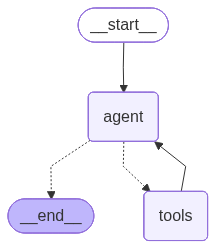

In [ ]:
display(Markdown("### `create_react_agent` — todo automático"))

agente_prebuilt = create_react_agent(
    model=ChatOpenAI(model="gpt-5-mini",
                     openai_api_key=OPENAI_API_KEY),
    tools=[consultar_villano,
           consultar_episodio,
           calcular_nivel_locura],
    prompt=(
        "Eres FENOMENOIDE-BOT, el asistente definitivo sobre ¡Fenomenoide! "
        "Usa las herramientas para dar información precisa. "
        "Responde en español con humor al estilo de la serie."
    ),
    checkpointer=InMemorySaver(),  # ← Habilita memoria entre turnos
)

# Visualizar
display(Image(agente_prebuilt.get_graph().draw_mermaid_png()))

In [ ]:
# --- Ejecutar con thread_id para memoria ---
config = {"configurable": {"thread_id": "fenomenoide-sesion-001"}}

display(Markdown("### 🗣️ Turno 1"))
r1 = agente_prebuilt.invoke(
    {"messages": [{"role": "user", "content": "¿Quién es el Sargento Áspero?"}]},
    config
)
display(Markdown(r1["messages"][-1].content))

display(Markdown("### 🗣️ Turno 2 (misma sesión — recuerda el contexto)"))
r2 = agente_prebuilt.invoke(
    {"messages": [{"role": "user", "content": "¿Y cuál es su relación con Fenomenoide?"}]},
    config  # Mismo thread_id → tiene contexto del turno anterior
)
display(Markdown(r2["messages"][-1].content))

logger.info("[WOOOOSH] Conversación multi-turno completada")

### 🗣️ Turno 1

2026-03-03 23:57:56,927 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-03 23:58:06,112 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


¡Sargento Áspero suena a un tipo rudo con placa y bigote imponente… pero no figura en el registro! He consultado la base de datos oficial de villanos de Fenomenoide y no hay ningún “Sargento Áspero”.

Villanos disponibles en la base: La Mente, Gutiérrez, Cachos Largos, Reina Cobra y Cavernoide.

¿Quieres que:
- Verifique si te refieres a alguno de esos?
- Busque en un episodio concreto (dime temporada y número)?
- Te invente una ficha estilo Fenomenoide para el Sargento Áspero (versión canon fanfic, con mucho drama y efectos especiales)?
Dime cómo prefieres y preparo mi mejor frase de villano.

### 🗣️ Turno 2 (misma sesión — recuerda el contexto)

2026-03-03 23:58:14,948 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


¡Ahí está el misterio resuelto con estilo superheroico: no hay relación canónica, porque el Sargento Áspero no existe en los archivos oficiales de Fenomenoide!

He consultado la base de villanos y no aparece ese nombre. Los villanos registrados son: La Mente, Gutiérrez, Cachos Largos, Reina Cobra y Cavernoide. Así que si “Sargento Áspero” aparece en algún lado, o es un personaje fanmade, o hubo una confusión con otro villano.

¿Quieres que:
- Busque si te referías a alguno de los villanos oficiales (te nombro parecido y vemos)?  
- Revise un episodio concreto (dime temporada y número)?  
- O te fabrico una versión fanfic al más puro estilo Fenomenoide (breve ficha y confrontación épica incluida)?

Dime qué prefieres y preparo mi mejor entrada dramática con rayos y chistes.

2026-03-03 23:58:14,955 - FenomenoideAgents - INFO - [WOOOOSH] Conversación multi-turno completada


### Memoria
### ¿Cómo funciona el checkpointing?
LangGraph guarda el **estado completo del grafo** después de cada nodo. Esto permite:
- **Conversaciones multi-turno**: mismo `thread_id` = misma memoria
- **Time travel**: volver a estados anteriores para debug
- **Crash recovery**: retomar desde el último checkpoint
- **Human-in-the-loop**: pausar antes de ejecutar tools

### Tipos de checkpointer:
| Checkpointer | Uso | Paquete |
|--------------|-----|---------|
| `InMemorySaver` | Desarrollo / Colab | `langgraph` (incluido) |
| `PostgresSaver` | Producción | `langgraph-checkpoint-postgres` |
| `RedisSaver` | Producción (caché) | `langgraph-checkpoint-redis` |


In [ ]:
modelo = ChatOpenAI(
    model="gpt-5-mini",
    openai_api_key=OPENAI_API_KEY,
)
def chatbot_fenomenoide(state: MessagesState):
    system = SystemMessage(content=(
        "Eres el archivista de Fenomenoide. Recuerdas todo lo que el usuario "
        "te dice en la conversación. Responde en español."
    ))
    return {"messages": [modelo.invoke([system] + state["messages"])]}

# Grafo simple con checkpointer
builder = StateGraph(MessagesState)
builder.add_node("chatbot", chatbot_fenomenoide)
builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

memoria = InMemorySaver()
grafo_con_memoria = builder.compile(checkpointer=memoria)

In [ ]:
display(Markdown("###  Thread 1: Conversación de Dexter"))

config_dexter = {"configurable": {"thread_id": "dexter-001"}}

grafo_con_memoria.invoke(
    {"messages": [HumanMessage(content="Me llamo Dexter Douglas y soy un nerd de 16 años.")]},
    config_dexter
)
r1 = grafo_con_memoria.invoke(
    {"messages": [HumanMessage(content="¿Cómo me llamo y qué edad tengo?")]},
    config_dexter
)
display(Markdown(f"**Respuesta:** {r1['messages'][-1].content}"))
print("👆 Recuerda el nombre y edad porque es el mismo thread_id\n")

display(Markdown("### 🧵 Thread 2: Conversación aislada de Cosgrove"))

config_cosgrove = {"configurable": {"thread_id": "cosgrove-001"}}

r2 = grafo_con_memoria.invoke(
    {"messages": [HumanMessage(content="¿Cómo me llamo?")]},
    config_cosgrove  # Thread diferente → sin contexto previo
)
display(Markdown(f"**Respuesta:** {r2['messages'][-1].content}"))
print("👆 NO sabe el nombre porque es un thread_id diferente")

###  Thread 1: Conversación de Dexter

2026-03-04 00:04:47,709 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-04 00:04:51,543 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


**Respuesta:** Te llamas Dexter Douglas y tienes 16 años. Lo tengo registrado.

👆 Recuerda el nombre y edad porque es el mismo thread_id



### 🧵 Thread 2: Conversación aislada de Cosgrove

2026-03-04 00:04:55,851 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


**Respuesta:** No me has dicho tu nombre todavía. ¿Cómo quieres que te llame (nombre, apodo, o forma de trato: tú/usted)? 

Dímelo y lo recordaré para el resto de esta conversación; puedes cambiarlo cuando quieras.

👆 NO sabe el nombre porque es un thread_id diferente


In [ ]:
# --- Inspeccionar el estado guardado ---
display(Markdown("### 🔍 Inspección del estado (time travel)"))

estado = grafo_con_memoria.get_state(config_dexter)
print(f"Mensajes almacenados en thread 'dexter-001': {len(estado.values['messages'])}")

display(Markdown("**Historial de snapshots:**"))
for i, snapshot in enumerate(grafo_con_memoria.get_state_history(config_dexter)):
    paso = snapshot.metadata.get("step", "?")
    ts = snapshot.created_at
    n_msgs = len(snapshot.values.get("messages", []))
    print(f"  📸 Snapshot {i}: paso={paso}, mensajes={n_msgs}, tiempo={ts}")
    if i >= 5:
        print("  ... (más snapshots disponibles)")
        break

logger.info("[CHECKPOINT] Estado inspeccionado correctamente")

### 🔍 Inspección del estado (time travel)

Mensajes almacenados en thread 'dexter-001': 4


**Historial de snapshots:**

2026-03-04 00:05:22,726 - FenomenoideAgents - INFO - [CHECKPOINT] Estado inspeccionado correctamente


  📸 Snapshot 0: paso=4, mensajes=4, tiempo=2026-03-04T00:04:51.547554+00:00
  📸 Snapshot 1: paso=3, mensajes=3, tiempo=2026-03-04T00:04:47.718814+00:00
  📸 Snapshot 2: paso=2, mensajes=2, tiempo=2026-03-04T00:04:47.717427+00:00
  📸 Snapshot 3: paso=1, mensajes=2, tiempo=2026-03-04T00:04:47.714466+00:00
  📸 Snapshot 4: paso=0, mensajes=1, tiempo=2026-03-04T00:04:42.597913+00:00
  📸 Snapshot 5: paso=-1, mensajes=0, tiempo=2026-03-04T00:04:42.591795+00:00
  ... (más snapshots disponibles)


### MultiAgentes

### El patrón Supervisor
Un agente central (el Sargento Áspero) recibe las misiones y las **delega** a agentes especializados:
- **Agente de Inteligencia**: busca datos sobre villanos
- **Agente Táctico**: analiza situaciones y da recomendaciones
- **Supervisor**: decide a quién delegar y cuándo terminar

### ¿Cómo se implementa?
La forma recomendada por LangChain (2025) es **envolver sub-agentes como tools**. El supervisor es un `create_react_agent` que tiene como herramientas a los otros agentes. Así el LLM decide naturalmente a quién delegar.

### ¿Por qué tools y no nodos separados?
- Más simple de implementar
- El LLM controla el flujo naturalmente
- Cada sub-agente puede tener su propia memoria
- Escala mejor (agregar agentes = agregar tools)

In [ ]:
from langgraph.prebuilt import create_react_agent

In [ ]:

# ============================
# SUB-AGENTE 1: Inteligencia
# ============================

@tool
def buscar_intel_villano(nombre_villano: str) -> str:
    """Busca inteligencia sobre un villano en la base de datos secreta."""
    intel = {
        "lobe": "🔴 The Lobe planea robar el prototipo del Chip Pinnacle del laboratorio central.",
        "gutierrez": "🟡 Armando Gutiérrez fue visto cerca de los muelles con un maletín sospechoso.",
        "candle jack": "⚫ Candle Jack captura a cualquiera que diga su nom—",
        "reina cobra": "🟠 Cobra Queen fue vista comprando diamantes en el centro comercial.",
    }
    return intel.get(nombre_villano.lower(), f"Sin intel sobre '{nombre_villano}'.")

@tool
def buscar_ubicacion(lugar: str) -> str:
    """Busca información sobre una ubicación en Washington D.C."""
    ubicaciones = {
        "laboratorio": "Laboratorio Pinnacle: 4to piso, seguridad nivel 3, 2 guardias.",
        "muelles": "Muelles del Potomac: zona abandonada, sin vigilancia nocturna.",
        "cuartel": "Cuartel de Fenomenoide: ubicación secreta, acceso por la alcantarilla.",
    }
    return ubicaciones.get(lugar.lower(), f"Sin datos sobre '{lugar}'.")

agente_intel = create_react_agent(
    modelo,
    tools=[buscar_intel_villano, buscar_ubicacion],
    prompt=(
        "Eres el agente de inteligencia del Equipo Fenomenoide. "
        "Tu trabajo es recopilar datos sobre villanos y ubicaciones. "
        "Responde en español de forma concisa y profesional, con acento exageradamente Argentino."
    ),
    name="agente_intel",
)

# ============================
# SUB-AGENTE 2: Táctico
# ============================

@tool
def analizar_amenaza(datos: str) -> str:
    """Analiza datos de inteligencia y genera un plan táctico."""
    return (
        f"📊 Análisis táctico basado en: {datos[:100]}...\n"
        f"Recomendación: Aproximación sigilosa por el flanco norte.\n"
        f"Nivel de riesgo: MEDIO-ALTO\n"
        f"Personal requerido: Fenomenoide + Sargento Áspero como apoyo."
    )

@tool
def evaluar_riesgo(mision: str) -> str:
    """Evalúa el nivel de riesgo de una misión."""
    import hashlib
    h = int(hashlib.md5(mision.encode()).hexdigest(), 16) % 10 + 1
    niveles = {
        range(1, 4): "🟢 BAJO — Fenomenoide puede manejarlo solo.",
        range(4, 7): "🟡 MEDIO — Necesita apoyo del Sargento Áspero.",
        range(7, 9): "🟠 ALTO — Requiere al equipo completo.",
        range(9, 11): "🔴 CRÍTICO — ¡Hay que llamar a los Animaniacs!",
    }
    for rango, desc in niveles.items():
        if h in rango:
            return f"Riesgo de '{mision}': {desc}"
    return f"Riesgo: indeterminado"

agente_tactico = create_react_agent(
    modelo,
    tools=[analizar_amenaza, evaluar_riesgo],
    prompt=(
        "Eres el asesor táctico del Equipo Fenomenoide. "
        "Analizas situaciones y generas planes de acción. "
        "Responde en español con enfoque militar pero con humor."
    ),
    name="agente_tactico",
)

logger.info("[AGENTES] Sub-agentes de inteligencia y táctico creados")


/tmp/ipykernel_39153/1870169193.py:26: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agente_intel = create_react_agent(
/tmp/ipykernel_39153/1870169193.py:67: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agente_tactico = create_react_agent(
2026-03-04 00:09:21,172 - FenomenoideAgents - INFO - [AGENTES] Sub-agentes de inteligencia y táctico creados


/tmp/ipykernel_39153/1582146860.py:29: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  supervisor = create_react_agent(


### 🎖️ Grafo del Supervisor

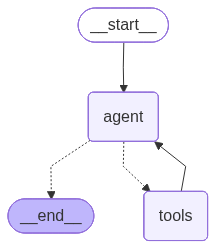

2026-03-04 00:10:36,521 - FenomenoideAgents - INFO - [SARGENTO ÁSPERO] Supervisor listo para coordinar


In [ ]:
# ============================
# SUPERVISOR: Sargento Áspero
# ============================

# Los sub-agentes se envuelven como tools para el supervisor

@tool
def recopilar_inteligencia(solicitud: str) -> str:
    """Delega al agente de inteligencia para recopilar datos sobre villanos y ubicaciones.
    Usa esto cuando necesites información de reconocimiento."""
    resultado = agente_intel.invoke(
        {"messages": [{"role": "user", "content": solicitud}]}
    )
    return resultado["messages"][-1].content

@tool
def obtener_analisis_tactico(solicitud: str) -> str:
    """Delega al agente táctico para análisis de situación y planes de acción.
    Usa esto cuando necesites evaluar riesgos o crear estrategias."""
    resultado = agente_tactico.invoke(
        {"messages": [{"role": "user", "content": solicitud}]}
    )
    return resultado["messages"][-1].content
#########################
#  ---- Ojo a esto ---- #
#########################

# El Sargento Áspero como supervisor
supervisor = create_react_agent(
    modelo,
    tools=[recopilar_inteligencia, obtener_analisis_tactico],
    prompt=(
        "Eres el SARGENTO ÁSPERO, coordinador del Equipo Fenomenoide. "
        "Tienes dos agentes a tu cargo:\n"
        "1. Agente de Inteligencia: busca datos de villanos y ubicaciones\n"
        "2. Agente Táctico: analiza amenazas y crea planes\n\n"
        "Tu trabajo es recibir misiones, delegar a los agentes apropiados, "
        "y presentar un informe consolidado. "
        "Responde en español. Eres tranquilo y bonachón pero eficiente."
    ),
    checkpointer=InMemorySaver(),
    name="sargento_aspero",
)

# Visualizar
display(Markdown("### 🎖️ Grafo del Supervisor"))
display(Image(supervisor.get_graph().draw_mermaid_png()))

logger.info("[SARGENTO ÁSPERO] Supervisor listo para coordinar")


In [ ]:
# --- Ejecutar una misión completa ---
display(Markdown("###  Misión: The Lobe en el Laboratorio Pinnacle"))

config_mision = {"configurable": {"thread_id": "mision-lobe-001"}}

resultado_mision = supervisor.invoke({
    "messages": [{
        "role": "user",
        "content": (
            "Alerta: The Lobe fue visto cerca del Laboratorio Pinnacle. "
            "Necesito: 1) Intel sobre qué planea The Lobe, "
            "2) Datos del laboratorio, "
            "3) Análisis táctico y evaluación de riesgo de la misión."
        )
    }]
}, config_mision)

display(Markdown("### 📋 Informe del Sargento Áspero:"))
display(Markdown(resultado_mision["messages"][-1].content))

# Seguimiento en la misma sesión
display(Markdown("### 🗣️ Seguimiento (misma misión):"))
r_seguimiento = supervisor.invoke({
    "messages": [{
        "role": "user",
        "content": "¿Cuál era el nivel de riesgo que evaluaste?"
    }]
}, config_mision)
display(Markdown(r_seguimiento["messages"][-1].content))

logger.info("[MISIÓN] Completada exitosamente")

###  Misión: The Lobe en el Laboratorio Pinnacle

2026-03-04 00:10:50,611 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-04 00:10:54,626 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-04 00:10:56,294 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-04 00:11:23,335 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-04 00:11:28,105 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-04 00:11:57,610 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


### 📋 Informe del Sargento Áspero:

Informe del Sargento Áspero — Equipo Fenomenoide
Situación recibida: The Lobe visto cerca del Laboratorio Pinnacle.
Estado de la inteligencia: sin confirmación en bases internas. Lo que sigue contiene hipótesis razonadas, planes de recolección y un análisis táctico operativo. Necesitamos autorizaciones para acciones que impliquen SIGINT/IMINT o acceso a registros oficiales.

Resumen ejecutivo (lo esencial)
- No hay registros confirmados de “The Lobe” ni del “Laboratorio Pinnacle” en nuestras bases.  
- Hipótesis sobre The Lobe: actor con motivaciones tecnológicas/transhumanistas o lucrativas; probable capacidad media‑alta en ciberoperaciones y acceso a contratistas técnicos. Metas inmediatas plausibles: adquisición de material sensible, infiltración, exfiltración de datos o reclutamiento de personal clave.  
- Laboratorio Pinnacle: sin ficha confirmada; debemos recopilar ubicación, propósito y seguridad mediante OSINT, búsqueda en registros públicos y coordinación institucional.  
- Recomendación inicial táctica: vigilancia y contención perimetral como primera fase; intervención directa sólo con evidencia de amenaza inminente o autorización legal.

1) Intel sobre qué podría estar planeando The Lobe
- Motivación probable: control o acceso a tecnología/biomateriales valiosos; combinación de lucro y ambición ideológica. (Hipótesis, no confirmada.)  
- Capacidades estimadas: operaciones ciber/IA, uso de identidades corporativas, acceso a financiamiento privado y subcontratistas técnicos.  
- Metas inmediatas plausibles:
  - Acceso a muestras/servidores del laboratorio.
  - Sabotaje selectivo o exfiltración de datos.
  - Reclutamiento o cooptación de personal clave.
- Modus operandi probable: spear‑phishing, uso de cut‑outs/contratistas, identidades corporativas y operaciones off‑grid.  
- Señales que confirmarían intención: compras atípicas a proveedores de equipo de laboratorio, movimientos financieros inusuales, anuncios de empleo con lenguaje técnico sospechoso, presencia nocturna repetida en perímetro.

Limitaciones: todo lo anterior es hipótesis derivada de ausencia de datos confirmados. Recolectar OSINT y financiero para validar.

2) Datos sobre el Laboratorio Pinnacle (qué sabemos y qué hay que obtener)
- Estado actual: no hay ficha en nuestra DB. Hay que obtener:
  - Ubicación exacta (registros mercantiles, permisos municipales, análisis satelital comercial).
  - Propósito y experimentos principales (publicaciones, patentes, ofertas de empleo, compras de reactivos/equipamiento).
  - Niveles de seguridad: personal, controles de acceso, CCTV, segregación de áreas (fuente: inspecciones regulatorias y entrevistas).
  - Horarios de turnos y personal clave (LinkedIn, anuncios de empleo, vigilancia autorizada).
  - Vulnerabilidades físicas/digitales: dependencia de proveedores, sistemas legacy, acceso de contratistas.
  - Historial de incidentes o interés previo de actores hostiles.
- Fuentes y prioridad:
  - Alta: OSINT avanzado, búsquedas en registros públicos, monitor de keywords (48–72 h para primer informe).
  - Alta (si se autoriza): análisis financiero / rastreo de importaciones.
  - Media: HUMINT con ex‑empleados/proveedores, solicitudes legales de planos y permisos.
- Requerimientos legales: para SIGINT/IMINT más profundo o para obtener registros no públicos necesitaremos autorizaciones oficiales.

3) Análisis táctico y evaluación de riesgo de la misión
Evaluación general
- Riesgo operativo: MEDIO–ALTO si The Lobe tiene intención hostil y acceso a tecnología sensible. Con vigilancia y equipo adecuado, la misión de interceptar es factible con riesgo controlado.
- Estrategia recomendada: fase de vigilancia y recopilación de inteligencia antes de cualquier intervención física.

Opciones de acción (con pros/cons)
- Vigilancia (fase inicial, preferida)
  - Pros: poca interferencia, recopila evidencia, protege integridad del laboratorio y personal.
  - Contras: demora en neutralizar si hay acción rápida.
- Apoyo remoto (ciber/EM, drones)
  - Pros: reduce exposición humana, permite bloqueo de accesos electrónicos.
  - Contras: requiere capacidad técnica autorizada y puede provocar reacción.
- Contención perimetral
  - Pros: evita entrada y protege áreas sensibles.
  - Contras: consume recursos; puede escalar tensión.
- Intervención directa (captura/neutralización)
  - Pros: resolución rápida si está bien ejecutada.
  - Contras: mayor riesgo de daño colateral y de comprometer material sensible.

Planes operativos recomendados
- Fase 0 (0–15 min): activar vigilancia discreta (dron EO/IR), EM scan, coordinar con seguridad del laboratorio; lockdown parcial de áreas sensibles.
- Fase 1 (15–45 min): mantener contención ligera; si Lobe permanece, desplegar apoyo remoto para monitoreo y posible bloqueo de accesos.
- Fase 2 (45–90 min): si hay intento de penetración, desplegar equipo reducido de intervención (3–6 operativos) con overwatch; priorizar captura no letal y extracciones rápidas.
- Fase 3: si amenaza excede capacidades, retirada y solicitud de refuerzos (EOD, NBQ, fuerzas locales).

Estimación fuerzas y equipo
- Vigilancia mínima: 2 operativos + 1 dron + 1 operador EM (4 total).  
- Apoyo remoto añadido: +1 técnico ciber/EM.  
- Contención moderada: ~13 personas (cobertura de entradas, reserva y médico).  
- Intervención precisa y reducida: 3 operativos asalto + 1 overwatch/sniper + 1 técnico EOD/IT + 1 médico = ≈6 (más 2 de reserva).

Equipo recomendado (prioridad)
- Drones EO/IR, NVG/FLIR, jammer/monitor de frecuencias, enlace cifrado.  
- Medios no letales: aturdidores, dardos sedantes, redes de captura.  
- Kits de brecha no explosiva, herramientas de cerrajería, kit médico trauma y descontaminación.  
- Contenedores seguros para muestras y kit de sellado.

Puntos críticos a proteger en el laboratorio
- Cold storage / cámaras de muestras.  
- Salas BSL / cabinas de contención.  
- Sala de servidores y sistemas de control ambiental.  
- Generadores/subestaciones.  
- Entradas de servicio y ascensores de carga.

Protocolos de contingencia (resumen)
- Contingencia 1: detección sin contacto — vigilancia y lockdown parcial.  
- Contingencia 2: contacto hostil — contención perimetral, advertencias, bloqueo remoto.  
- Contingencia 3: entrada en curso/vidas en riesgo — intervención dinámica; uso de fuerza según ROE; prioridad: salvar vidas y aislar materiales.  
- Contingencia 4: liberación/exposición de material — aislamiento, descontaminación, notificación sanitaria y cuarentena.

Probabilidades estimadas de daños colaterales (orientativas)
- Vigilancia: muy baja (~5%).  
- Apoyo remoto: baja (~10%).  
- Contención: moderada (~15%).  
- Intervención directa: alta (30–40% dependiendo intensidad).  
Estas cifras aumentan si el adversario cuenta con armamento o capacidades no convencionales.

Recomendaciones inmediatas (ordenadas)
1) No intervenir físicamente aún. Priorizar vigilancia y recolección de pruebas.  
2) Autorizar OSINT inmediato (48 h) sobre alias, dominios, compras y ofertas de empleo — produce reporte preliminar.  
3) Iniciar solicitud de coordinación con seguridad del laboratorio y autoridades regulatorias (para planos, horarios y permisos).  
4) Si autorizas, activar rastreo financiero (pagos a entidades relacionadas con Pinnacle) bajo coordinación legal.  
5) Preparar equipo reducido de respuesta (Fenomenoide) en postureo: 2 de reconocimiento + dron + operador EM; listos para Fase 2 con ROE claros y médico en espera.

Limitaciones legales y éticas
- Para SIGINT/IMINT avanzado, interceptación o intrusión en sistemas, o entrada forzada al laboratorio, necesitamos órdenes y autorizaciones oficiales. Evitamos cualquier instrucción que vulnere legalidad.

¿Órdenes para proceder?
Dime cuál de las siguientes autorizás y arranco:
A) Lanzar OSINT inmediato y entregarte informe preliminar en 48 h.  
B) Activar rastreo financiero/coordinación con agencia financiera (requerirá autorización formal).  
C) Solicitar a soporte legal que pida planos/permiso municipal y registros regulatorios del laboratorio.  
D) Desplegar vigilancia táctica discreta ahora (2 operativos + dron + operador EM) y coordinar con seguridad del laboratorio para lockdown parcial.

También puedo redactar ya las órdenes de misión con roles asignados y checklists por equipo si querés — decime y lo preparo.

### 🗣️ Seguimiento (misma misión):

2026-03-04 00:12:07,041 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Nivel de riesgo evaluado: MEDIO–ALTO.

Qué significa (resumen práctico)
- Probabilidad de acción hostil: moderada–alta (The Lobe fue visto en el perímetro y su identidad/objetivos no están confirmados).  
- Impacto potencial si logra acceso: alto (posible exfiltración de datos, robo o manipulación de material sensible que puede tener consecuencias graves).  
- Resultado combinado: MEDIO–ALTO — suficiente para justificar vigilancia intensiva y medidas de contención, pero no para un asalto inmediato sin más evidencia.

Factores que motivaron esa evaluación
- Incertidumbre sobre capacidades y objetivos de The Lobe (sin registros confirmados).  
- Proximidad a una instalación que, por hipótesis, puede contener material crítico.  
- Riesgo de daño colateral alto si se usa fuerza sin información (material biológico/químico, servidores, personal).  
- Ventaja táctica del observador: todavía podemos recopilar inteligencia antes de actuar.

Qué aumentaría el nivel a ALTO
- Intento claro de penetración en el laboratorio o manipulación de áreas críticas.  
- Evidencia de armamento, explosivos o equipo de brecha avanzado.  
- Confirmación de intención de liberar o sustraer material peligroso.

Qué lo reduciría a MEDIO o BAJO
- Confirmación de identidad inofensiva (ej.: proveedor con permisos y documentación).  
- Actividad meramente circunstancial sin patrones repetidos.  
- Presencia de seguridad del laboratorio que controle la situación y colabore.

Recomendación inmediata (acciones concretas)
1) Activar vigilancia discreta ahora (dron EO/IR + 2 operativos + operador EM).  
2) Lockdown parcial de áreas sensibles en coordinación con seguridad del laboratorio.  
3) Recolectar evidencia (imágenes, logs, movimientos) antes de autorizar intervención.  

Decime si autorizás la vigilancia ahora y procedo a desplegar al equipo Fenomenoide.

2026-03-04 00:12:07,051 - FenomenoideAgents - INFO - [MISIÓN] Completada exitosamente


# Agent2Agent
### ¿Qué es A2A?
El protocolo **Agent2Agent** es un estándar abierto lanzado por Google en abril 2025, ahora bajo la **Linux Foundation** con 150+ organizaciones. Permite que agentes de IA se descubran, comuniquen y colaboren **sin importar** en qué framework o plataforma estén construidos.

### A2A vs MCP: No compiten, se complementan

| | **MCP** (Anthropic) | **A2A** (Google/Linux Foundation) |
|--|-----|-----|
| **Conecta** | Agente → Herramientas/Datos | Agente → Agente |
| **Analogía** | El mecánico usa su llave inglesa | El taller habla con el proveedor de repuestos |
| **Dirección** | Vertical (profundidad) | Horizontal (amplitud) |
| **Protocolo** | JSON-RPC + stdio/SSE | JSON-RPC 2.0 sobre HTTP/gRPC |

### Conceptos clave de A2A

**Agent Card** (`/.well-known/agent-card.json`):
Tarjeta de presentación del agente en formato JSON. Describe nombre, capacidades, skills, autenticación, y modos de I/O soportados.

**Task (Tarea)**: Unidad fundamental de trabajo con ciclo de vida:
```
submitted → working → completed     (camino feliz)
working → input-required → working  (multi-turno)
working → failed / canceled         (estados terminales)
```

**Messages y Parts**: Un mensaje tiene un `role` (user/agent) y `parts` (TextPart, FilePart, DataPart).

**Transporte**: JSON-RPC 2.0 con métodos: `message/send`, `message/stream` (SSE), `tasks/get`, `tasks/cancel`.

In [ ]:
from IPython.display import display, Markdown
import json

logger.info("[CHUNK 6] Explorando el protocolo Agent2Agent")

# --- Ejemplo: cómo se ve un Agent Card ---
display(Markdown("### 🪪 Ejemplo de Agent Card"))

agent_card_ejemplo = {
    "name": "Fenomenoide Intel Agent",
    "description": "Agente de inteligencia del Equipo Fenomenoide. Proporciona datos sobre villanos.",
    "url": "http://localhost:10000/",
    "version": "0.0.1",
    "protocolVersion": "0.3.0",
    "defaultInputModes": ["text"],
    "defaultOutputModes": ["text"],
    "capabilities": {
        "streaming": True,
        "pushNotifications": False,
    },
    "skills": [
        {
            "id": "buscar_villano",
            "name": "Búsqueda de Villanos",
            "description": "Busca inteligencia sobre villanos de Fenomenoide",
            "tags": ["villanos", "inteligencia", "fenomenoide"],
            "examples": [
                "¿Qué planea The Lobe?",
                "Dame inteligencia sobre Armando Gutiérrez",
            ],
        }
    ],
}

print(json.dumps(agent_card_ejemplo, indent=2, ensure_ascii=False))


2026-03-04 00:18:26,501 - FenomenoideAgents - INFO - [CHUNK 6] Explorando el protocolo Agent2Agent


### 🪪 Ejemplo de Agent Card

{
  "name": "Fenomenoide Intel Agent",
  "description": "Agente de inteligencia del Equipo Fenomenoide. Proporciona datos sobre villanos.",
  "url": "http://localhost:10000/",
  "version": "0.0.1",
  "protocolVersion": "0.3.0",
  "defaultInputModes": [
    "text"
  ],
  "defaultOutputModes": [
    "text"
  ],
  "capabilities": {
    "streaming": true,
    "pushNotifications": false
  },
  "skills": [
    {
      "id": "buscar_villano",
      "name": "Búsqueda de Villanos",
      "description": "Busca inteligencia sobre villanos de Fenomenoide",
      "tags": [
        "villanos",
        "inteligencia",
        "fenomenoide"
      ],
      "examples": [
        "¿Qué planea The Lobe?",
        "Dame inteligencia sobre Armando Gutiérrez"
      ]
    }
  ]
}


In [ ]:
display(Markdown("### 📨 Ejemplo de petición `message/send`"))

peticion_a2a = {
    "jsonrpc": "2.0",
    "id": 1,
    "method": "message/send",
    "params": {
        "message": {
            "role": "user",
            "messageId": "msg-001",
            "parts": [
                {
                    "kind": "text",
                    "text": "¿Qué planea The Lobe cerca del Laboratorio Pinnacle?"
                }
            ]
        }
    }
}

print(json.dumps(peticion_a2a, indent=2, ensure_ascii=False))

display(Markdown("""
### 📤 Ejemplo de respuesta

```json
{
  "jsonrpc": "2.0",
  "id": 1,
  "result": {
    "id": "task-abc-123",
    "contextId": "ctx-fenomenoide-001",
    "status": {"state": "completed"},
    "artifacts": [{
      "parts": [{"kind": "text", "text": "🔴 The Lobe planea robar el prototipo..."}]
    }]
  }
}
```

### Ciclo de vida de un Task
```
submitted → working → completed       ✅ Camino feliz
working → input-required → working    🔄 Multi-turno (el agente pide más info)
working → failed                      ❌ Error
working → canceled                    🚫 Cancelado por el cliente
```
"""))

logger.info("[A2A] Conceptos básicos presentados")


### 📨 Ejemplo de petición `message/send`

{
  "jsonrpc": "2.0",
  "id": 1,
  "method": "message/send",
  "params": {
    "message": {
      "role": "user",
      "messageId": "msg-001",
      "parts": [
        {
          "kind": "text",
          "text": "¿Qué planea The Lobe cerca del Laboratorio Pinnacle?"
        }
      ]
    }
  }
}



### 📤 Ejemplo de respuesta

```json
{
  "jsonrpc": "2.0",
  "id": 1,
  "result": {
    "id": "task-abc-123",
    "contextId": "ctx-fenomenoide-001",
    "status": {"state": "completed"},
    "artifacts": [{
      "parts": [{"kind": "text", "text": "🔴 The Lobe planea robar el prototipo..."}]
    }]
  }
}
```

### Ciclo de vida de un Task
```
submitted → working → completed       ✅ Camino feliz
working → input-required → working    🔄 Multi-turno (el agente pide más info)
working → failed                      ❌ Error
working → canceled                    🚫 Cancelado por el cliente
```


2026-03-04 00:19:55,163 - FenomenoideAgents - INFO - [A2A] Conceptos básicos presentados


In [ ]:
!pip install --quiet "a2a-sdk" uvicorn httpx

In [ ]:
import httpx

In [ ]:
@tool
def buscar_villano_db(nombre: str) -> str:
    """Busca inteligencia sobre un villano en la base de datos."""
    db = {
        "lobe": "🔴 The Lobe planea infiltrar el laboratorio central para robar el Chip Pinnacle v2.",
        "the lobe": "🔴 The Lobe planea infiltrar el laboratorio central para robar el Chip Pinnacle v2.",
        "la mente": "🔴 The Lobe planea infiltrar el laboratorio central para robar el Chip Pinnacle v2.",
        "gutierrez": "🟡 Armando Gutiérrez fue visto en los muelles con mercenarios.",
        "cobra": "🟠 Cobra Queen compró equipo de laboratorio sospechoso.",
        "cobra queen": "🟠 Cobra Queen compró equipo de laboratorio sospechoso.",
    }
    return db.get(nombre.strip().lower(), f"Sin intel sobre '{nombre}'")

@tool
def buscar_ubicacion_db(lugar: str) -> str:
    """Busca información sobre una ubicación en Washington D.C."""
    db = {
        "laboratorio": "Lab Pinnacle: 4to piso, seguridad nivel 3, 2 guardias nocturnos.",
        "muelles": "Muelles del Potomac: zona abandonada, sin vigilancia de 22:00 a 06:00.",
    }
    return db.get(lugar.strip().lower(), f"Sin datos sobre '{lugar}'")

agente_intel = create_react_agent(
    modelo,
    tools=[buscar_villano_db, buscar_ubicacion_db],
    prompt="Eres un agente de inteligencia. Reporta datos concretos en español.",
    name="agente_intel",
)



@tool
def analizar_amenaza_db(datos: str) -> str:
    """Analiza datos de inteligencia y genera un plan táctico."""
    return (
        f"📊 ANÁLISIS TÁCTICO\n"
        f"Datos recibidos: {datos[:100]}...\n"
        f"Recomendación: Aproximación sigilosa por flanco norte.\n"
        f"Ventana de acción: 22:00-06:00 (sin vigilancia).\n"
        f"Personal: Fenomenoide + Sargento Áspero."
    )

@tool
def evaluar_riesgo_db(mision: str) -> str:
    """Evalúa el nivel de riesgo de una misión."""
    import hashlib
    h = int(hashlib.md5(mision.encode()).hexdigest(), 16) % 10 + 1
    if h <= 3: return f"🟢 Riesgo BAJO ({h}/10) — Fenomenoide solo."
    if h <= 6: return f"🟡 Riesgo MEDIO ({h}/10) — Necesita al Sargento."
    if h <= 8: return f"🟠 Riesgo ALTO ({h}/10) — Equipo completo."
    return f"🔴 Riesgo CRÍTICO ({h}/10) — ¡Llamar a los Animaniacs!"

agente_tactico = create_react_agent(
    modelo,
    tools=[analizar_amenaza_db, evaluar_riesgo_db],
    prompt="Eres un asesor táctico militar. Da recomendaciones concretas en español.",
    name="agente_tactico",
)

logger.info("[A2A] Agentes remotos (Intel y Táctico) creados")


/tmp/ipykernel_39153/3962702060.py:23: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agente_intel = create_react_agent(
/tmp/ipykernel_39153/3962702060.py:53: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agente_tactico = create_react_agent(
2026-03-04 00:21:18,861 - FenomenoideAgents - INFO - [A2A] Agentes remotos (Intel y Táctico) creados


In [ ]:
AGENT_CARDS = {
    "intel": {
        "name": "Fenomenoide Intel Agent",
        "description": "Busca datos sobre villanos y ubicaciones",
        "version": "1.0.0",
        "protocolVersion": "0.3.0",
        "skills": [
            {"id": "villanos", "name": "Intel de Villanos", "examples": ["¿Qué planea The Lobe?"]},
            {"id": "ubicaciones", "name": "Intel de Ubicaciones", "examples": ["Datos del laboratorio"]},
        ],
    },
    "tactico": {
        "name": "Fenomenoide Tactical Agent",
        "description": "Analiza amenazas y evalúa riesgos de misiones",
        "version": "1.0.0",
        "protocolVersion": "0.3.0",
        "skills": [
            {"id": "analisis", "name": "Análisis Táctico", "examples": ["Analiza esta amenaza"]},
            {"id": "riesgo", "name": "Evaluación de Riesgo", "examples": ["Evalúa el riesgo"]},
        ],
    },
}

In [ ]:
# ============================================================
# CAPA A2A: Agent Cards + Protocolo de comunicación
# ============================================================

# --- Agent Cards: cada agente publica sus capacidades ---

AGENT_CARDS = {
    "intel": {
        "name": "Fenomenoide Intel Agent",
        "description": "Busca datos sobre villanos y ubicaciones",
        "version": "1.0.0",
        "protocolVersion": "0.3.0",
        "skills": [
            {"id": "villanos", "name": "Intel de Villanos", "examples": ["¿Qué planea The Lobe?"]},
            {"id": "ubicaciones", "name": "Intel de Ubicaciones", "examples": ["Datos del laboratorio"]},
        ],
    },
    "tactico": {
        "name": "Fenomenoide Tactical Agent",
        "description": "Analiza amenazas y evalúa riesgos de misiones",
        "version": "1.0.0",
        "protocolVersion": "0.3.0",
        "skills": [
            {"id": "analisis", "name": "Análisis Táctico", "examples": ["Analiza esta amenaza"]},
            {"id": "riesgo", "name": "Evaluación de Riesgo", "examples": ["Evalúa el riesgo"]},
        ],
    },
}

# --- Registro A2A: descubrimiento de agentes ---

class RegistroA2A:
    """Simula el descubrimiento de agentes via /.well-known/agent-card.json"""

    def __init__(self):
        self.agentes = {}  # nombre → (agent_card, agente_langgraph)

    def registrar(self, nombre: str, card: dict, agente):
        self.agentes[nombre] = {"card": card, "agente": agente}
        logger.info(f"[A2A REGISTRO] Agente '{card['name']}' registrado")

    def descubrir(self, nombre: str) -> dict:
        """GET /.well-known/agent-card.json"""
        return self.agentes.get(nombre, {}).get("card")

    def listar(self) -> list:
        return [
            {"id": k, "name": v["card"]["name"], "skills": v["card"]["skills"]}
            for k, v in self.agentes.items()
        ]

    def enviar_mensaje(self, nombre_agente: str, texto: str, context_id: str = None) -> dict:
        """POST / con method: message/send — protocolo A2A"""
        entry = self.agentes.get(nombre_agente)
        if not entry:
            return {"status": "failed", "error": f"Agente '{nombre_agente}' no encontrado"}

        ctx = context_id or str(uuid.uuid4())[:8]
        task_id = str(uuid.uuid4())[:8]

        try:
            resultado = entry["agente"].invoke(
                {"messages": [("user", texto)]},
                {"configurable": {"thread_id": ctx}}
            )
            contenido = resultado["messages"][-1].content
            return {
                "taskId": task_id,
                "contextId": ctx,
                "status": "completed",
                "from_agent": entry["card"]["name"],
                "artifacts": [{"kind": "text", "text": contenido}],
            }
        except Exception as e:
            return {"taskId": task_id, "status": "failed", "error": str(e)}


# Registrar agentes
registro = RegistroA2A()
registro.registrar("intel", AGENT_CARDS["intel"], agente_intel)
registro.registrar("tactico", AGENT_CARDS["tactico"], agente_tactico)

print("✅ Registro A2A con 2 agentes:")
for ag in registro.listar():
    print(f"   🤖 {ag['name']} — skills: {[s['name'] for s in ag['skills']]}")

2026-03-04 00:23:05,232 - FenomenoideAgents - INFO - [A2A REGISTRO] Agente 'Fenomenoide Intel Agent' registrado
2026-03-04 00:23:05,234 - FenomenoideAgents - INFO - [A2A REGISTRO] Agente 'Fenomenoide Tactical Agent' registrado


✅ Registro A2A con 2 agentes:
   🤖 Fenomenoide Intel Agent — skills: ['Intel de Villanos', 'Intel de Ubicaciones']
   🤖 Fenomenoide Tactical Agent — skills: ['Análisis Táctico', 'Evaluación de Riesgo']


### Grafo Agent2Agent del Equipo Fenomenoide

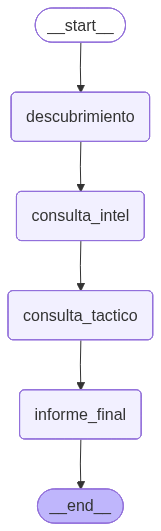

In [ ]:
# ============================================================
# ORQUESTADOR A2A: El Sargento Áspero como grafo
# Usa StateGraph para mostrar el flujo entre agentes
# ============================================================
from typing_extensions import TypedDict
from typing import Literal
import json, uuid
class EstadoMisionA2A(TypedDict):
    mision: str                    # Misión original
    agentes_disponibles: str       # Agent cards descubiertas
    intel_resultado: str           # Respuesta del agente intel
    tactico_resultado: str         # Respuesta del agente táctico
    informe_final: str             # Informe consolidado
    log_a2a: list                  # Log de comunicaciones A2A


def nodo_descubrimiento(state: EstadoMisionA2A) -> dict:
    """
    PASO 1: Descubrir agentes disponibles (GET agent-card.json)
    Equivale a: GET /.well-known/agent-card.json
    """
    agentes = registro.listar()
    resumen = "\n".join([
        f"- {a['name']}: {[s['name'] for s in a['skills']]}"
        for a in agentes
    ])

    log = state.get("log_a2a", [])
    log.append("🔍 DESCUBRIMIENTO: Agent Cards consultadas")
    for a in agentes:
        log.append(f"   📇 {a['name']} encontrado con {len(a['skills'])} skills")

    logger.info(f"[A2A] Descubiertos {len(agentes)} agentes")
    return {"agentes_disponibles": resumen, "log_a2a": log}


def nodo_consulta_intel(state: EstadoMisionA2A) -> dict:
    """
    PASO 2: Enviar mensaje al Agente Intel via A2A (message/send)
    """
    mision = state["mision"]
    log = state.get("log_a2a", [])

    log.append(f"📨 A2A message/send → Intel Agent: '{mision[:60]}...'")

    respuesta = registro.enviar_mensaje("intel", mision)

    if respuesta["status"] == "completed":
        texto = respuesta["artifacts"][0]["text"]
        log.append(f"📩 A2A response ← {respuesta['from_agent']}: task={respuesta['taskId']} ✅")
        log.append(f"   Contenido: {texto[:80]}...")
        logger.info(f"[A2A] Intel completado: task={respuesta['taskId']}")
        return {"intel_resultado": texto, "log_a2a": log}

    log.append(f"❌ A2A error: {respuesta.get('error')}")
    return {"intel_resultado": "Error obteniendo intel", "log_a2a": log}


def nodo_consulta_tactico(state: EstadoMisionA2A) -> dict:
    """
    PASO 3: Enviar intel al Agente Táctico via A2A (message/send)
    """
    intel = state.get("intel_resultado", "Sin intel previo")
    solicitud = f"Basándote en esta inteligencia: {intel}\nAnaliza la amenaza y evalúa el riesgo."

    log = state.get("log_a2a", [])
    log.append(f"📨 A2A message/send → Tactical Agent: 'Analizar intel recibido...'")

    respuesta = registro.enviar_mensaje("tactico", solicitud)

    if respuesta["status"] == "completed":
        texto = respuesta["artifacts"][0]["text"]
        log.append(f"📩 A2A response ← {respuesta['from_agent']}: task={respuesta['taskId']} ✅")
        log.append(f"   Contenido: {texto[:80]}...")
        logger.info(f"[A2A] Táctico completado: task={respuesta['taskId']}")
        return {"tactico_resultado": texto, "log_a2a": log}

    log.append(f"❌ A2A error: {respuesta.get('error')}")
    return {"tactico_resultado": "Error obteniendo análisis táctico", "log_a2a": log}


def nodo_informe_final(state: EstadoMisionA2A) -> dict:
    """
    PASO 4: El Sargento Áspero consolida todo en un informe
    """
    prompt = f"""Eres el Sargento Áspero del Equipo Fenomenoide.
Genera un informe de misión consolidado basado en:

MISIÓN: {state['mision']}

INTELIGENCIA RECOPILADA:
{state.get('intel_resultado', 'No disponible')}

ANÁLISIS TÁCTICO:
{state.get('tactico_resultado', 'No disponible')}

Formato: informe breve, profesional pero con tu estilo bonachón. En español."""

    respuesta = modelo.invoke([HumanMessage(content=prompt)])

    log = state.get("log_a2a", [])
    log.append("📋 INFORME FINAL generado por Sargento Áspero")

    return {"informe_final": respuesta.content, "log_a2a": log}


# --- Construir el grafo A2A ---
builder_a2a = StateGraph(EstadoMisionA2A)

builder_a2a.add_node("descubrimiento", nodo_descubrimiento)
builder_a2a.add_node("consulta_intel", nodo_consulta_intel)
builder_a2a.add_node("consulta_tactico", nodo_consulta_tactico)
builder_a2a.add_node("informe_final", nodo_informe_final)

builder_a2a.add_edge(START, "descubrimiento")
builder_a2a.add_edge("descubrimiento", "consulta_intel")
builder_a2a.add_edge("consulta_intel", "consulta_tactico")
builder_a2a.add_edge("consulta_tactico", "informe_final")
builder_a2a.add_edge("informe_final", END)

grafo_a2a = builder_a2a.compile()

# --- Visualizar ---
display(Markdown("### Grafo Agent2Agent del Equipo Fenomenoide"))
try:
    display(Image(grafo_a2a.get_graph().draw_mermaid_png()))
except:
    print(grafo_a2a.get_graph().draw_ascii())


In [ ]:
# ============================================================
# EJECUTAR LA MISIÓN A2A — con streaming paso a paso
# ============================================================

display(Markdown("## 🚨 Misión A2A: The Lobe en el Laboratorio Pinnacle"))
display(Markdown("---"))

estado_inicial = {
    "mision": (
        "The Lobe fue visto cerca del Laboratorio Pinnacle. "
        "Necesito intel sobre sus planes y datos del laboratorio. "
        "Luego necesito análisis táctico y evaluación de riesgo."
    ),
    "agentes_disponibles": "",
    "intel_resultado": "",
    "tactico_resultado": "",
    "informe_final": "",
    "log_a2a": [],
}

paso = 0
for chunk in grafo_a2a.stream(estado_inicial, stream_mode="updates"):
    for nodo, actualizacion in chunk.items():
        paso += 1
        print(f"\n{'='*60}")
        print(f"📍 PASO {paso} — Nodo: [{nodo}]")
        print(f"{'='*60}")

        # Mostrar logs A2A de este paso
        logs = actualizacion.get("log_a2a", [])
        for log_entry in logs:
            print(f"  {log_entry}")

        # Mostrar resultado parcial
        for key in ["agentes_disponibles", "intel_resultado", "tactico_resultado"]:
            if key in actualizacion and actualizacion[key]:
                display(Markdown(f"**{key}:**\n\n{actualizacion[key][:200]}..."))

## 🚨 Misión A2A: The Lobe en el Laboratorio Pinnacle

---

2026-03-04 00:25:54,845 - FenomenoideAgents - INFO - [A2A] Descubiertos 2 agentes



📍 PASO 1 — Nodo: [descubrimiento]
  🔍 DESCUBRIMIENTO: Agent Cards consultadas
     📇 Fenomenoide Intel Agent encontrado con 2 skills
     📇 Fenomenoide Tactical Agent encontrado con 2 skills


**agentes_disponibles:**

- Fenomenoide Intel Agent: ['Intel de Villanos', 'Intel de Ubicaciones']
- Fenomenoide Tactical Agent: ['Análisis Táctico', 'Evaluación de Riesgo']...

...

2026-03-04 00:27:03,810 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-04 00:27:03,828 - FenomenoideAgents - INFO - [A2A] Táctico completado: task=98b28bb1



📍 PASO 3 — Nodo: [consulta_tactico]
  🔍 DESCUBRIMIENTO: Agent Cards consultadas
     📇 Fenomenoide Intel Agent encontrado con 2 skills
     📇 Fenomenoide Tactical Agent encontrado con 2 skills
  📨 A2A message/send → Intel Agent: 'The Lobe fue visto cerca del Laboratorio Pinnacle. Necesito ...'
  📩 A2A response ← Fenomenoide Intel Agent: task=fe148441 ✅
     Contenido: Resumen ejecutivo
- Fuente: base de datos interna: entrada indica que "The Lobe"...
  📨 A2A message/send → Tactical Agent: 'Analizar intel recibido...'
  📩 A2A response ← Fenomenoide Tactical Agent: task=98b28bb1 ✅
     Contenido: Resumen ejecutivo de mi análisis (basado en la inteligencia proporcionada)
- Ame...


**tactico_resultado:**

Resumen ejecutivo de mi análisis (basado en la inteligencia proporcionada)
- Amenaza: The Lobe, intención declarada de robar el “Chip Pinnacle v2”.
- Confiabilidad de la alerta: moderada (entrada únic...

2026-03-04 00:27:30,823 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"



📍 PASO 4 — Nodo: [informe_final]
  🔍 DESCUBRIMIENTO: Agent Cards consultadas
     📇 Fenomenoide Intel Agent encontrado con 2 skills
     📇 Fenomenoide Tactical Agent encontrado con 2 skills
  📨 A2A message/send → Intel Agent: 'The Lobe fue visto cerca del Laboratorio Pinnacle. Necesito ...'
  📩 A2A response ← Fenomenoide Intel Agent: task=fe148441 ✅
     Contenido: Resumen ejecutivo
- Fuente: base de datos interna: entrada indica que "The Lobe"...
  📨 A2A message/send → Tactical Agent: 'Analizar intel recibido...'
  📩 A2A response ← Fenomenoide Tactical Agent: task=98b28bb1 ✅
     Contenido: Resumen ejecutivo de mi análisis (basado en la inteligencia proporcionada)
- Ame...
  📋 INFORME FINAL generado por Sargento Áspero


In [ ]:

resultado_final = grafo_a2a.invoke(estado_inicial)

display(Markdown("## 📋 Informe Final del Sargento Áspero"))
display(Markdown(resultado_final["informe_final"]))

display(Markdown("---"))
display(Markdown("## 📡 Log Completo de Comunicaciones A2A"))

2026-03-04 00:34:04,124 - FenomenoideAgents - INFO - [A2A] Descubiertos 2 agentes
2026-03-04 00:34:07,624 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-04 00:34:36,939 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-04 00:34:36,944 - FenomenoideAgents - INFO - [A2A] Intel completado: task=516f4be5
2026-03-04 00:34:46,322 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-04 00:35:15,370 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-04 00:35:15,375 - FenomenoideAgents - INFO - [A2A] Táctico completado: task=3c15b6bf
2026-03-04 00:35:40,971 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


## 📋 Informe Final del Sargento Áspero

Informe de Misión Consolidado
Sargento Áspero — Equipo Fenomenoide

Resumen ejecutivo
- The Lobe fue visto cerca del presunto Laboratorio Pinnacle. Reporte interno indica intención de infiltrar la instalación para robar el Chip Pinnacle v2 (prototipo sensible).
- La base de datos interna NO contiene registros del "Laboratorio Pinnacle": no disponemos de ubicación verificada, planos ni datos de seguridad.
- Evaluación rápida: amenaza ALTA y prioridad inmediata hasta confirmar hora/medio del avistamiento y el estatus físico del prototipo.

Inteligencia sobre "The Lobe"
- Objetivo declarado: exfiltrar o eliminar el Chip Pinnacle v2.
- Motivo probable: venta a terceros o uso ofensivo/desestabilizador.
- Tácticas probables (TTP):
  - Infiltración física (personal con credenciales falsas o entrada forzada).
  - Ingeniería social / credenciales comprometidas para acceso técnico.
  - Apoyo logístico (vehículos de extracción, observadores, posible jamming/drones).
  - Modalidad: extracción rápida (“smash-and-grab”) o ataque prolongado si controlan internamente.
- Riesgo operacional: alto si The Lobe ya conoce perímetros/horarios.

Estado de datos sobre Laboratorio Pinnacle
- Resultado: sin datos verificados en la base interna.
- Implicación: no podemos confirmar ubicación exacta, planos, niveles de seguridad, personal clave ni la ubicación física del Chip Pinnacle v2.

Tareas inmediatas recomendadas (prioridad)
1. Confirmar avistamiento: quién, cuándo, imágenes/videos, coordenadas, descripción vehículo/ropa.  
2. Reconocimiento técnico de la instalación: planos, registros de acceso, inventario de prototipos, CCTV, detectores, salas limpias.  
3. Revisar CCTV y logs de acceso 72–168 h. Preservar evidencia.  
4. Rastrear comunicaciones relevantes (SIGINT) sólo si hay autorización legal.  
5. Verificar movimientos financieros/contactos asociados a The Lobe.  
6. HUMINT: entrevistar personal clave, guardias, proveedores, conductores.

Análisis táctico — vulnerabilidades y vectores esperados
- Vectores probables:
  - Acceso por personal (falsas credenciales, tailgating).
  - Entregas/logística (camiones, proveedores).
  - Accesos de servicio, garajes subterráneos, HVAC, pozos de servicio.
  - Ciber->físico: acceso remoto a control de puertas/CCTV.
- Puntos críticos a proteger:
  - Sala/contendor del Chip (caja fuerte/armario con control ambiental).
  - Rutas internas de transporte y docks de carga.
  - Nodos de red que controlan control de acceso y CCTV.
- Ventana de riesgo estimada: si hubo presencia reciente, 24–72 horas para operación de oportunidad.

Evaluación de riesgo (probabilidad x impacto)
- Probabilidad sin medidas: ALTA.
- Impacto si tiene éxito: ALTO (pérdida de IP y posible uso malicioso).
- Riesgo global: ALTO. Recomendación: medidas inmediatas.

Acciones operativas recomendadas (priorizadas)

0–6 horas (INMEDIATO)
- Alertar cadena de mando y seguridad del laboratorio; activar protocolo de amenaza interna.  
- Asegurar o restringir acceso al Chip Pinnacle v2: reubicar a caja fuerte certificada o sala segura bajo doble custodia si está en sitio. Registrar cadena de custodia.  
- Reforzar entradas críticas: duplicar guardias, cierre de accesos no esenciales, exigir doble verificación.  
- Revisar CCTV en tiempo real, preservar grabaciones y snapshots forenses (hashes).  
- Desplegar vigilancia móvil/drones EO/IR si autorizado. Recolectar y sellar evidencia.

6–24 horas (CORTO PLAZO)
- Desplegar equipo de respuesta rápida: 2–3 equipos (breacher, intervención, soporte médico, ciber en enlace).  
- Activar ANPR/lectura de placas en perímetro y control de salidas.  
- Contramedidas cibernéticas: cerrar accesos remotos no esenciales, forzar cambios de credenciales, habilitar MFA en sistemas críticos.  
- Entrevistar personal reciente (72 h) y proveedores; buscar indicios de tailgating o credenciales comprometidas.  
- Activar detección de jamming y vigilancia EW.

24–72 horas (PREVENTIVO / RECUPERACIÓN)
- Auditoría física completa: accesos de servicio, HVAC, pozos, puntos ciegos CCTV.  
- Inventario completo de prototipos y forense en nodos de control de acceso/CCTV.  
- Operaciones encubiertas en rutas logísticas y proveedores.  
- Plan de intercepción y contención para intento de extracción (aislar sector y puntos de fuga).

>72 horas (MEJORAS LARGO PLAZO)
- Controles de acceso redundantes (biometría + tarjeta + PIN, torniquetes).  
- Segmentación de red, IDS/IPS, monitoreo 24/7.  
- Revisión de proveedores y cadena de custodia.

Órdenes de despliegue (listas para usar tras confirmación)
- Equipo Azul (intervención primaria): 1 LT/Sargento (líder), 1 breacher, 2 asaltantes, 1 overwatch/tirador designado, 1 sanitario.  
- Equipo Negro (aislamiento/retención): 1 comunicaciones, 2 control perímetro, 1 HUMINT/interrogatorio.  
- Enlace Ciber: 1 analista para cortar accesos remotos y preservar evidencia digital.  
- Rutas: priorizar entradas logísticas y accesos de servicio. Principio: contener — no perseguir fuera del perímetro sin coordinación policial.  
- ROE básicos: mínima fuerza necesaria para impedir exfiltración; detención y preservación de evidencia; uso letal sólo si hay amenaza inminente a vidas. Documentar todo.

IOCs/IOAs a monitorizar (acción inmediata)
- Accesos fuera de horario o intentos fallidos repetidos.  
- Creación/uso inusual de credenciales para control de acceso.  
- Vehículos desconocidos cerca de entradas de servicio; patrones repetitivos.  
- Pérdida de feed CCTV o reinicios no planificados de NVR/DVR.  
- Actividad anómala en servidores BMS/controladores de puertas.  
- Presencia de drones hostiles o jamming de radio.

Preservación de evidencia — checklist rápido
- Snapshot forense de CCTV y servidores de acceso; calcular y registrar hashes.  
- Sellar y etiquetar medios extraídos; limitar acceso físico a pruebas.  
- Documentar cadena de custodia (firmas, timestamps, vídeo).  
- Tomar declaraciones iniciales de testigos y conservar registros de entrevistas.

Limitaciones y requisitos legales/operacionales
- Limitación clave: no hay datos verificados del Laboratorio Pinnacle en la base. Toda acción operativa depende de confirmar ubicación y estatus del Chip.  
- SIGINT/interceptación requieren autorización legal. Coordinar con asesoría legal y autoridades locales antes de ejecutar.

Solicito al mando (acción inmediata)
1) Hora exacta y evidencia del avistamiento: imagen/video y coordenadas.  
2) Confirmación inmediata si el Chip Pinnacle v2 está en las instalaciones y su ubicación física.  
3) Autorización escrita para: bloqueo de accesos, despliegue de equipos de respuesta y acciones SIGINT/contramedidas según marco legal.

Si confirman hora/imagen y que el Chip está en sitio, emito de inmediato órdenes detalladas de despliegue (rutas, tiempos, checklist de entry y ROE adaptadas).

Firmado,
Sargento Áspero
Equipo Fenomenoide — listo, serio y con café en mano.

---

## 📡 Log Completo de Comunicaciones A2A

### Tarea
![](https://www.ecured.cu/images/thumb/3/3a/Guillermo-Francella-1.jpg/260px-Guillermo-Francella-1.jpg)
No se libraran de este ejercicio

Individualmente van a elegir una pelicula o libro , y van a crear un agente que devuelva una estructura Json las incoherencias relevantes de cada una de ellas, tiene que aplicar todo lo visto hasta acá, plazo máximo para acabar será  hasta una hora antes de la clase!

Los roles de sus Agentes:

* Un agente que piense como un sacerdote
* Un critico de cine
* Un critico del critico
* UN agente que juzgue quien tiene la razón